# Notebook 13 — v1.1 Research Synthesis and Final Report

## Purpose

This notebook consolidates the final evidence from **Derivative Pricing Project v1.1** into a clean, auditable research summary.

It does **not** introduce new pricing models, recalibrate existing models, pull new market data, or modify the modeling results from earlier notebooks. Its purpose is to summarize the completed v1.1 workflow, freeze the final claims, and prepare the project for GitHub/portfolio presentation.

## Project stance

The v1.1 project follows a staged derivatives-pricing workflow:

1. no-arbitrage replication and binomial pricing foundations  
2. Brownian motion, GBM, quadratic variation, and Ito calculus foundations  
3. Black-Scholes PDE, closed-form pricing, Greeks, and numerical checks  
4. risk-neutral Monte Carlo and delta-hedging error analysis  
5. implied-volatility inversion and no-arbitrage bounds  
6. SPY option-chain ingestion, quote filtering, and surface-grade IV construction  
7. static-arbitrage diagnostics for the raw empirical IV surface  
8. arbitrage-aware SVI/SSVI repair and handoff construction  
9. Heston/Bates calibration, validation, and model-risk diagnostics  

## Final research claim

For the single SPY option-chain date studied, the repaired/simple implied-volatility surface is the preferred representation of the volatility surface.

The calibrated Bates model materially improves over Heston and is useful as a parametric diagnostic and stress-testing layer, but it does **not** beat the best simple IV surface baseline on IV RMSE. Therefore, Bates should not be treated as the final surface representation.

## Final use policy

- Use the repaired/simple IV surface for surface representation.
- Use Bates only as a parametric diagnostic and stress-testing layer.
- Do not use Heston as the final calibrated model.
- Do not claim production pricing readiness.
- Do not claim temporal out-of-sample robustness.
- Treat the project as a single-date research and model-risk study.

## Governing rule for this notebook

Notebook 13 is a synthesis notebook.

It should be auditable, boring, and precise. Every final claim must trace back to saved v1.1 artifacts from Notebooks 10, 11, or 12.

In [1]:
# ============================================================
# Notebook 13 — Setup, imports, and run policy
# ============================================================
#
# This notebook is a synthesis/report notebook.
#
# Rules:
#   1. Do not pull new market data.
#   2. Do not recalibrate Heston or Bates.
#   3. Do not repair or refit SVI/SSVI surfaces.
#   4. Do not run Monte Carlo simulations.
#   5. Only load saved v1.1 artifacts and summarize final evidence.
# ============================================================

from __future__ import annotations

import json
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Display discipline
# ------------------------------------------------------------

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


# ------------------------------------------------------------
# Reproducibility metadata
# ------------------------------------------------------------

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

NOTEBOOK_NAME = "13_v1_1_research_synthesis_and_final_report"
PROJECT_VERSION = "v1.1"
NOTEBOOK_ROLE = "research_synthesis_only"

NO_NEW_MARKET_DATA_PULL = True
NO_NEW_CALIBRATION = True
NO_NEW_SURFACE_REPAIR = True
NO_MONTE_CARLO = True
NO_PRODUCTION_PRICING_CLAIM = True
NO_TEMPORAL_OOS_CLAIM = True


# ------------------------------------------------------------
# Local project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(r"D:/Derivative Pricing Project v1.0+/V1.1")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

N13_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_NAME
N13_TABLE_DIR = N13_OUTPUT_DIR / "tables"
N13_FIGURE_DIR = N13_OUTPUT_DIR / "figures"
N13_REPORT_DIR = N13_OUTPUT_DIR / "reports"
N13_MANIFEST_DIR = N13_OUTPUT_DIR / "manifest"
N13_LOG_DIR = N13_OUTPUT_DIR / "logs"

for directory in [
    N13_OUTPUT_DIR,
    N13_TABLE_DIR,
    N13_FIGURE_DIR,
    N13_REPORT_DIR,
    N13_MANIFEST_DIR,
    N13_LOG_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Notebook 13 run configuration
# ------------------------------------------------------------

n13_run_config = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "notebook_role": NOTEBOOK_ROLE,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "project_root": str(PROJECT_ROOT),
    "outputs_dir": str(OUTPUTS_DIR),
    "n13_output_dir": str(N13_OUTPUT_DIR),
    "policy": {
        "no_new_market_data_pull": NO_NEW_MARKET_DATA_PULL,
        "no_new_calibration": NO_NEW_CALIBRATION,
        "no_new_surface_repair": NO_NEW_SURFACE_REPAIR,
        "no_monte_carlo": NO_MONTE_CARLO,
        "no_production_pricing_claim": NO_PRODUCTION_PRICING_CLAIM,
        "no_temporal_oos_claim": NO_TEMPORAL_OOS_CLAIM,
    },
    "environment": {
        "python_version": sys.version,
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    },
}

N13_RUN_CONFIG_PATH = N13_LOG_DIR / f"n13_run_config_{RUN_TIMESTAMP_UTC}.json"
N13_RUN_CONFIG_LATEST_PATH = N13_LOG_DIR / "n13_run_config_latest.json"

for path in [N13_RUN_CONFIG_PATH, N13_RUN_CONFIG_LATEST_PATH]:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(n13_run_config, f, indent=2)

print("Notebook 13 setup complete.")
print(f"Run timestamp UTC: {RUN_TIMESTAMP_UTC}")
print(f"Output directory: {N13_OUTPUT_DIR}")

Notebook 13 setup complete.
Run timestamp UTC: 20260706T174818Z
Output directory: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report


In [3]:
# ============================================================
# Notebook 13 — Artifact registry and availability audit
# ============================================================
#
# Purpose:
#   Resolve final v1.1 artifacts needed for synthesis.
#
# Design decision:
#   Notebook 13 is downstream of the completed v1.1 modeling layer.
#   The hard dependency is Notebook 12's final model-risk package.
#
#   Notebook 10 artifacts are useful context, but they are not allowed
#   to block the final synthesis when Notebook 11 and Notebook 12 have
#   already consumed Notebook 10 and produced valid downstream handoffs.
#
#   Therefore:
#       - N11 and N12 terminal artifacts are REQUIRED.
#       - N10 final tables are OPTIONAL_CONTEXT.
#       - N10 status can be reconstructed from paths.txt / registry constants.
# ============================================================


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def path_exists(path: Path | str) -> bool:
    """Return True if a path exists."""
    return Path(path).exists()


def read_table(path: Path | str) -> pd.DataFrame:
    """
    Read a table from CSV or Parquet.

    Raises
    ------
    ValueError
        If the file suffix is unsupported.
    FileNotFoundError
        If the path does not exist.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing table: {path}")

    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported table suffix for {path}")


def read_json(path: Path | str) -> dict[str, Any]:
    """Read a JSON file."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def write_latest_and_timestamped_csv(df: pd.DataFrame, stem: str, output_dir: Path) -> tuple[Path, Path]:
    """
    Write a timestamped CSV and a latest CSV copy.

    Returns
    -------
    tuple[Path, Path]
        (timestamped_path, latest_path)
    """
    timestamped_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}.csv"
    latest_path = output_dir / f"{stem}_latest.csv"

    df.to_csv(timestamped_path, index=False)
    df.to_csv(latest_path, index=False)

    return timestamped_path, latest_path


def write_latest_and_timestamped_json(payload: dict[str, Any], stem: str, output_dir: Path) -> tuple[Path, Path]:
    """
    Write a timestamped JSON and a latest JSON copy.

    Returns
    -------
    tuple[Path, Path]
        (timestamped_path, latest_path)
    """
    timestamped_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}.json"
    latest_path = output_dir / f"{stem}_latest.json"

    for path in [timestamped_path, latest_path]:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2)

    return timestamped_path, latest_path


# ------------------------------------------------------------
# Upstream output directories
# ------------------------------------------------------------

N10_OUTPUT_DIR = OUTPUTS_DIR / "10_raw_static_arbitrage_diagnostics_for_spy_iv_surface"
N10_TABLE_DIR = N10_OUTPUT_DIR / "tables"
N10_HANDOFF_DIR = N10_OUTPUT_DIR / "handoff"
N10_MANIFEST_DIR = N10_OUTPUT_DIR / "manifest"

N11_OUTPUT_DIR = OUTPUTS_DIR / "11_arbitrage_aware_svi_ssvi_surface_repair_and_handoff"
N11_TABLE_DIR = N11_OUTPUT_DIR / "tables"
N11_HANDOFF_DIR = N11_OUTPUT_DIR / "handoff"
N11_MANIFEST_DIR = N11_OUTPUT_DIR / "manifest"
N11_GRID_DIR = N11_OUTPUT_DIR / "surface_grids"

N12_OUTPUT_DIR = OUTPUTS_DIR / "12_model_calibration_validation_and_surface_risk_diagnostics"
N12_TABLE_DIR = N12_OUTPUT_DIR / "tables"
N12_ARTIFACT_DIR = N12_OUTPUT_DIR / "artifacts"
N12_MODEL_DIR = N12_OUTPUT_DIR / "models"
N12_HANDOFF_DIR = N12_OUTPUT_DIR / "handoff"
N12_LOG_DIR = N12_OUTPUT_DIR / "logs"
N12_FIGURE_DIR = N12_OUTPUT_DIR / "figures"


# ------------------------------------------------------------
# Reconstructed upstream status constants
# ------------------------------------------------------------

upstream_status_registry = {
    "n10_status": "READY_FOR_11_WITH_WARNINGS",
    "n10_status_reason": (
        "Notebook 11 can proceed using the broad handoff, but convexity warnings "
        "must be treated as repair/downweighting inputs."
    ),
    "n11_status": "READY_FOR_12_WITH_WARNINGS",
    "n11_status_reason": (
        "Notebook 12 can proceed using the selected clean repaired handoff. "
        "Four selected rows carry repair-bias warnings, but no selected row has "
        "a repair-fail flag or localized static-proxy warning."
    ),
    "n12_status": "COMPLETE",
    "n12_final_verdict": "CONDITIONAL_PASS",
    "n12_model_risk_level": "elevated_but_usable_for_diagnostics",
    "n12_status_reason": (
        "Notebook 12 completed the v1.1 terminal model-risk layer. Bates materially "
        "improves over Heston and beats the fair price hurdle, but misses the fair IV "
        "hurdle and does not beat the best simple IV surface baseline. Use the repaired "
        "surface or simple surface baseline for surface representation, and Bates only "
        "as a parametric diagnostic/stress layer."
    ),
}


# ------------------------------------------------------------
# Artifact registry
# ------------------------------------------------------------

artifact_registry = {
    # ----------------------------
    # Notebook 10 optional context
    # ----------------------------
    "n10_final_status_table": {
        "path": N10_TABLE_DIR / "final_status_table_latest.csv",
        "required": False,
        "role": "optional_context",
        "stage": "n10",
        "loader": "table",
    },
    "n10_final_validation_ledger": {
        "path": N10_TABLE_DIR / "final_validation_ledger_latest.csv",
        "required": False,
        "role": "optional_context",
        "stage": "n10",
        "loader": "table",
    },
    "n10_handoff_inventory": {
        "path": N10_HANDOFF_DIR / "handoff_inventory_latest.csv",
        "required": False,
        "role": "optional_context",
        "stage": "n10",
        "loader": "table",
    },
    "n10_handoff_by_expiry": {
        "path": N10_HANDOFF_DIR / "handoff_by_expiry_latest.csv",
        "required": False,
        "role": "optional_context",
        "stage": "n10",
        "loader": "table",
    },
    "n10_handoff_by_bucket": {
        "path": N10_HANDOFF_DIR / "handoff_by_bucket_latest.csv",
        "required": False,
        "role": "optional_context",
        "stage": "n10",
        "loader": "table",
    },

    # ----------------------------
    # Notebook 11 required evidence
    # ----------------------------
    "n11_final_status_table": {
        "path": N11_TABLE_DIR / "n11_final_status_table_latest.parquet",
        "required": True,
        "role": "required_evidence",
        "stage": "n11",
        "loader": "table",
    },
    "n11_final_handoff_summary": {
        "path": N11_TABLE_DIR / "n11_final_handoff_summary_latest.parquet",
        "required": True,
        "role": "required_evidence",
        "stage": "n11",
        "loader": "table",
    },
    "n11_final_handoff_by_expiry": {
        "path": N11_TABLE_DIR / "n11_final_handoff_by_expiry_latest.parquet",
        "required": False,
        "role": "recommended_context",
        "stage": "n11",
        "loader": "table",
    },
    "n11_final_handoff_by_bucket": {
        "path": N11_TABLE_DIR / "n11_final_handoff_by_bucket_latest.parquet",
        "required": False,
        "role": "recommended_context",
        "stage": "n11",
        "loader": "table",
    },
    "n11_final_validation_ledger": {
        "path": N11_TABLE_DIR / "n11_final_validation_ledger_latest.parquet",
        "required": False,
        "role": "recommended_context",
        "stage": "n11",
        "loader": "table",
    },
    "n11_final_manifest": {
        "path": N11_MANIFEST_DIR / "n11_final_manifest_latest.json",
        "required": True,
        "role": "required_evidence",
        "stage": "n11",
        "loader": "json",
    },
    "n11_to_n12_selected_handoff": {
        "path": N11_HANDOFF_DIR / "n11_to_n12_selected_repaired_handoff_latest.parquet",
        "required": False,
        "role": "recommended_context",
        "stage": "n11",
        "loader": "table",
    },
    "n11_to_n12_selected_repaired_grid": {
        "path": N11_GRID_DIR / "n11_to_n12_selected_repaired_surface_grid_latest.parquet",
        "required": False,
        "role": "recommended_context",
        "stage": "n11",
        "loader": "table",
    },

    # ----------------------------
    # Notebook 12 required terminal package
    # ----------------------------
    "n12_final_model_comparison": {
        "path": N12_TABLE_DIR / "n12_final_model_comparison_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_model_risk_verdict": {
        "path": N12_TABLE_DIR / "n12_model_risk_verdict_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_model_use_policy": {
        "path": N12_TABLE_DIR / "n12_model_use_policy_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_model_risk_warning_inventory": {
        "path": N12_TABLE_DIR / "n12_model_risk_warning_inventory_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_final_handoff_summary": {
        "path": N12_TABLE_DIR / "n12_final_handoff_summary_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_final_parameter_handoff": {
        "path": N12_TABLE_DIR / "n12_final_model_parameter_handoff_latest.csv",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "table",
    },
    "n12_calibration_hurdles": {
        "path": N12_TABLE_DIR / "n12_calibration_hurdles_latest.csv",
        "required": False,
        "role": "recommended_context",
        "stage": "n12",
        "loader": "table",
    },
    "n12_baseline_validation_summary": {
        "path": N12_TABLE_DIR / "n12_baseline_validation_summary_latest.csv",
        "required": False,
        "role": "recommended_context",
        "stage": "n12",
        "loader": "table",
    },
    "n12_stop_marker": {
        "path": N12_LOG_DIR / "n12_v1_1_modeling_layer_stop_marker_latest.json",
        "required": True,
        "role": "terminal_evidence",
        "stage": "n12",
        "loader": "json",
    },
    "n12_final_handoff_readme": {
        "path": N12_LOG_DIR / "n12_final_handoff_readme_latest.md",
        "required": False,
        "role": "recommended_context",
        "stage": "n12",
        "loader": "text",
    },
}


# ------------------------------------------------------------
# Availability audit
# ------------------------------------------------------------

artifact_availability = pd.DataFrame(
    [
        {
            "artifact_key": key,
            "stage": meta["stage"],
            "role": meta["role"],
            "required": bool(meta["required"]),
            "loader": meta["loader"],
            "path": str(meta["path"]),
            "exists": Path(meta["path"]).exists(),
            "suffix": Path(meta["path"]).suffix.lower(),
        }
        for key, meta in artifact_registry.items()
    ]
).sort_values(["stage", "required", "artifact_key"], ascending=[True, False, True])

artifact_availability_path, artifact_availability_latest_path = write_latest_and_timestamped_csv(
    artifact_availability,
    "n13_artifact_availability_audit",
    N13_TABLE_DIR,
)

display(artifact_availability)


# ------------------------------------------------------------
# Required-artifact gate
# ------------------------------------------------------------

missing_required = artifact_availability.query("required == True and exists == False").copy()

if not missing_required.empty:
    raise FileNotFoundError(
        "Notebook 13 cannot proceed because required terminal artifacts are missing:\n"
        + "\n".join(missing_required["path"].tolist())
    )

missing_optional = artifact_availability.query("required == False and exists == False").copy()

if missing_optional.empty:
    optional_status_msg = "All optional/recommended context artifacts are available."
else:
    optional_status_msg = (
        f"{len(missing_optional)} optional/recommended context artifact(s) are missing. "
        "Notebook 13 will proceed using available downstream evidence."
    )

print("Required v1.1 terminal artifacts are available.")
print(optional_status_msg)


# ------------------------------------------------------------
# Load available artifacts
# ------------------------------------------------------------

loaded_artifacts: dict[str, Any] = {}
load_failures: list[dict[str, str]] = []

for key, meta in artifact_registry.items():
    path = Path(meta["path"])

    if not path.exists():
        continue

    try:
        if meta["loader"] == "table":
            loaded_artifacts[key] = read_table(path)
        elif meta["loader"] == "json":
            loaded_artifacts[key] = read_json(path)
        elif meta["loader"] == "text":
            loaded_artifacts[key] = path.read_text(encoding="utf-8")
        else:
            raise ValueError(f"Unsupported loader: {meta['loader']}")

    except Exception as exc:
        load_failures.append(
            {
                "artifact_key": key,
                "path": str(path),
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            }
        )

load_failure_df = pd.DataFrame(load_failures)

if not load_failure_df.empty:
    display(load_failure_df)

    failed_required_keys = set(load_failure_df["artifact_key"]).intersection(
        {
            key
            for key, meta in artifact_registry.items()
            if meta["required"]
        }
    )

    if failed_required_keys:
        raise RuntimeError(
            "Notebook 13 failed to load required artifacts:\n"
            + "\n".join(sorted(failed_required_keys))
        )

print(f"Loaded artifacts: {len(loaded_artifacts)}")


# ------------------------------------------------------------
# Compact loaded-artifact summary
# ------------------------------------------------------------

loaded_artifact_summary_rows = []

for key, obj in loaded_artifacts.items():
    meta = artifact_registry[key]

    if isinstance(obj, pd.DataFrame):
        shape = f"{obj.shape[0]} rows x {obj.shape[1]} cols"
        columns_preview = ", ".join(obj.columns.astype(str).tolist()[:10])
    elif isinstance(obj, dict):
        shape = f"{len(obj)} top-level keys"
        columns_preview = ", ".join(list(obj.keys())[:10])
    elif isinstance(obj, str):
        shape = f"{len(obj):,} characters"
        columns_preview = obj[:120].replace("\n", " ")
    else:
        shape = type(obj).__name__
        columns_preview = ""

    loaded_artifact_summary_rows.append(
        {
            "artifact_key": key,
            "stage": meta["stage"],
            "role": meta["role"],
            "loader": meta["loader"],
            "shape_or_size": shape,
            "preview": columns_preview,
            "path": str(meta["path"]),
        }
    )

loaded_artifact_summary = pd.DataFrame(loaded_artifact_summary_rows).sort_values(
    ["stage", "artifact_key"]
)

loaded_artifact_summary_path, loaded_artifact_summary_latest_path = write_latest_and_timestamped_csv(
    loaded_artifact_summary,
    "n13_loaded_artifact_summary",
    N13_TABLE_DIR,
)

display(loaded_artifact_summary)


# ------------------------------------------------------------
# Save synthesis input manifest
# ------------------------------------------------------------

n13_input_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "upstream_status_registry": upstream_status_registry,
    "artifact_availability_path": str(artifact_availability_path),
    "artifact_availability_latest_path": str(artifact_availability_latest_path),
    "loaded_artifact_summary_path": str(loaded_artifact_summary_path),
    "loaded_artifact_summary_latest_path": str(loaded_artifact_summary_latest_path),
    "required_artifacts_loaded": bool(missing_required.empty),
    "missing_optional_artifact_count": int(len(missing_optional)),
    "loaded_artifact_count": int(len(loaded_artifacts)),
    "load_failure_count": int(len(load_failures)),
    "loaded_artifact_keys": sorted(loaded_artifacts.keys()),
    "missing_optional_artifacts": missing_optional[
        ["artifact_key", "stage", "role", "path"]
    ].to_dict(orient="records"),
}

n13_input_manifest_path, n13_input_manifest_latest_path = write_latest_and_timestamped_json(
    n13_input_manifest,
    "n13_input_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 artifact registry complete.")
print(f"Input manifest: {n13_input_manifest_latest_path}")

,artifact_key,stage,role,required,loader,path,exists,suffix
0,n10_final_status_table,n10,optional_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,False,.csv
1,n10_final_validation_ledger,n10,optional_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,False,.csv
4,n10_handoff_by_bucket,n10,optional_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,False,.csv
3,n10_handoff_by_expiry,n10,optional_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,False,.csv
2,n10_handoff_inventory,n10,optional_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,False,.csv
6,n11_final_handoff_summary,n11,required_evidence,True,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,.parquet
10,n11_final_manifest,n11,required_evidence,True,json,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,.json
5,n11_final_status_table,n11,required_evidence,True,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,.parquet
8,n11_final_handoff_by_bucket,n11,recommended_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,.parquet
7,n11_final_handoff_by_expiry,n11,recommended_context,False,table,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,.parquet


Required v1.1 terminal artifacts are available.
5 optional/recommended context artifact(s) are missing. Notebook 13 will proceed using available downstream evidence.
Loaded artifacts: 18


,artifact_key,stage,role,loader,shape_or_size,preview,path
3,n11_final_handoff_by_bucket,n11,recommended_context,table,4 rows x 12 cols,"n12_handoff_bucket, moneyness_region_n11, rows...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
2,n11_final_handoff_by_expiry,n11,recommended_context,table,8 rows x 17 cols,"expiry, rows, unique_strikes, min_tau, max_tau...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
1,n11_final_handoff_summary,n11,required_evidence,table,4 rows x 20 cols,"handoff_name, rows, expiries, unique_strikes, ...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
5,n11_final_manifest,n11,required_evidence,json,23 top-level keys,"notebook_id, notebook_name, run_tag, final_sta...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
0,n11_final_status_table,n11,required_evidence,table,1 rows x 21 cols,"notebook_id, notebook_name, run_tag, final_sta...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
4,n11_final_validation_ledger,n11,recommended_context,table,16 rows x 5 cols,"check_name, check_type, passes, observed_value...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
6,n11_to_n12_selected_handoff,n11,recommended_context,table,1250 rows x 80 cols,"contract_key, n11_run_tag, n11_candidate_label...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
7,n11_to_n12_selected_repaired_grid,n11,recommended_context,table,2896 rows x 23 cols,"grid_name, mode_name, expiry, tau_years, k, sv...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
15,n12_baseline_validation_summary,n12,recommended_context,table,40 rows x 26 cols,"run_tag, validation_family, model_name, model_...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...
14,n12_calibration_hurdles,n12,recommended_context,table,8 rows x 10 cols,"run_tag, hurdle_name, reference_model, validat...",D:\Derivative Pricing Project v1.0+\V1.1\outpu...


Notebook 13 artifact registry complete.
Input manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_input_manifest_latest.json


In [4]:
# ============================================================
# Notebook 13 — Final claim registry and project-use policy
# ============================================================
#
# Purpose:
#   Convert the loaded v1.1 terminal evidence into a compact,
#   reader-facing claim/use-policy table.
#
# This cell does not recompute model results.
# It only summarizes the already-completed v1.1 evidence.
# ============================================================


# ------------------------------------------------------------
# Helper functions for robust artifact extraction
# ------------------------------------------------------------

def first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return the first candidate column that exists in df."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


def scalar_from_df(
    df: pd.DataFrame,
    candidates: list[str],
    default: Any = None,
    row: int = 0,
) -> Any:
    """Extract a scalar from the first existing candidate column."""
    col = first_existing_column(df, candidates)

    if col is None:
        return default

    if df.empty:
        return default

    value = df.iloc[row][col]

    if pd.isna(value):
        return default

    return value


def safe_bool_text(value: Any) -> str:
    """Render booleans and missing values cleanly for report tables."""
    if pd.isna(value) if not isinstance(value, (list, dict, str)) else False:
        return "unknown"

    if isinstance(value, (bool, np.bool_)):
        return "yes" if bool(value) else "no"

    text = str(value).strip()

    if text.lower() in {"true", "1", "yes"}:
        return "yes"

    if text.lower() in {"false", "0", "no"}:
        return "no"

    return text


def normalize_permission(value: Any) -> str:
    """Normalize permission-like text."""
    if value is None:
        return "unknown"

    text = str(value).strip()

    if not text:
        return "unknown"

    return text


def get_loaded_df(key: str) -> pd.DataFrame:
    """Return a loaded DataFrame artifact or an empty DataFrame."""
    obj = loaded_artifacts.get(key)

    if isinstance(obj, pd.DataFrame):
        return obj.copy()

    return pd.DataFrame()


def get_loaded_json(key: str) -> dict[str, Any]:
    """Return a loaded JSON artifact or an empty dict."""
    obj = loaded_artifacts.get(key)

    if isinstance(obj, dict):
        return dict(obj)

    return {}


# ------------------------------------------------------------
# Pull terminal evidence
# ------------------------------------------------------------

n11_status_table = get_loaded_df("n11_final_status_table")
n11_handoff_summary = get_loaded_df("n11_final_handoff_summary")
n11_validation_ledger = get_loaded_df("n11_final_validation_ledger")
n11_manifest = get_loaded_json("n11_final_manifest")

n12_model_comparison = get_loaded_df("n12_final_model_comparison")
n12_model_risk_verdict = get_loaded_df("n12_model_risk_verdict")
n12_model_use_policy = get_loaded_df("n12_model_use_policy")
n12_warning_inventory = get_loaded_df("n12_model_risk_warning_inventory")
n12_final_handoff_summary = get_loaded_df("n12_final_handoff_summary")
n12_parameter_handoff = get_loaded_df("n12_final_parameter_handoff")
n12_stop_marker = get_loaded_json("n12_stop_marker")


# ------------------------------------------------------------
# Extract final verdict fields
# ------------------------------------------------------------

final_verdict = scalar_from_df(
    n12_model_risk_verdict,
    ["final_verdict", "verdict", "model_risk_verdict"],
    default=upstream_status_registry["n12_final_verdict"],
)

model_risk_level = scalar_from_df(
    n12_model_risk_verdict,
    ["model_risk_level", "risk_level"],
    default=upstream_status_registry["n12_model_risk_level"],
)

selected_surface_model = scalar_from_df(
    n12_model_risk_verdict,
    ["selected_surface_model", "surface_model", "final_surface_model"],
    default="expiry_quadratic_k_iv",
)

selected_parametric_model = scalar_from_df(
    n12_model_risk_verdict,
    ["selected_parametric_model", "parametric_model", "final_parametric_model"],
    default="bates_calibrated",
)

low_complexity_baseline = scalar_from_df(
    n12_model_risk_verdict,
    ["low_complexity_reference_baseline", "low_complexity_baseline"],
    default="global_surface_quadratic_iv",
)

best_simple_baseline = scalar_from_df(
    n12_model_risk_verdict,
    ["best_simple_reference_baseline", "best_simple_baseline"],
    default="expiry_quadratic_k_iv",
)

production_permission = scalar_from_df(
    n12_model_risk_verdict,
    ["production_pricing_permission", "production_permission"],
    default="not_allowed",
)

temporal_oos_allowed = scalar_from_df(
    n12_model_risk_verdict,
    ["temporal_oos_claim_allowed", "temporal_oos_allowed"],
    default=False,
)

publication_permission = scalar_from_df(
    n12_model_risk_verdict,
    ["publication_claim_permission", "publication_permission"],
    default="allowed_with_precise_language",
)


# ------------------------------------------------------------
# Pull model-use-policy artifact if available
# ------------------------------------------------------------

use_policy_clean = n12_model_use_policy.copy()

if not use_policy_clean.empty:
    use_policy_clean.columns = [str(c).strip() for c in use_policy_clean.columns]

    use_policy_path, use_policy_latest_path = write_latest_and_timestamped_csv(
        use_policy_clean,
        "n13_loaded_model_use_policy",
        N13_TABLE_DIR,
    )

    display(use_policy_clean)
else:
    use_policy_path = None
    use_policy_latest_path = None


# ------------------------------------------------------------
# Final claim registry
# ------------------------------------------------------------

claim_registry_rows = [
    {
        "claim_area": "Surface representation",
        "permission": "allowed",
        "final_position": f"Use `{selected_surface_model}` / repaired-simple IV surface representation.",
        "evidence_basis": (
            "Notebook 12 selects the simple/repaired IV surface layer as the final surface representation."
        ),
        "allowed_language": (
            "For the single SPY quote date studied, the repaired/simple implied-volatility "
            "surface is the preferred surface representation."
        ),
        "not_allowed_language": (
            "Do not claim the calibrated parametric model is the final production surface."
        ),
    },
    {
        "claim_area": "Bates model",
        "permission": "allowed_with_warnings",
        "final_position": f"Use `{selected_parametric_model}` only as a parametric diagnostic and stress-testing layer.",
        "evidence_basis": (
            "Bates materially improves over Heston and beats the fair price hurdle, "
            "but misses the fair IV hurdle and does not beat the best simple IV baseline."
        ),
        "allowed_language": (
            "Bates is useful as a parametric diagnostic/stress-testing model, but not "
            "as the preferred surface representation."
        ),
        "not_allowed_language": (
            "Do not claim Bates dominates all baselines or is production-ready."
        ),
    },
    {
        "claim_area": "Heston model",
        "permission": "not_recommended",
        "final_position": "Treat Heston as a diagnostic negative control.",
        "evidence_basis": (
            "Notebook 12 identifies Heston as materially weaker than Bates and not recommended "
            "as the final calibrated model."
        ),
        "allowed_language": (
            "Heston was useful as a baseline stochastic-volatility comparison."
        ),
        "not_allowed_language": (
            "Do not use Heston as the final calibrated model."
        ),
    },
    {
        "claim_area": "Production pricing",
        "permission": normalize_permission(production_permission),
        "final_position": "Production pricing is not allowed.",
        "evidence_basis": (
            "The project is based on a single quote date and carries elevated model-risk limitations."
        ),
        "allowed_language": (
            "This is a research and model-risk diagnostic workflow, not a production pricing system."
        ),
        "not_allowed_language": (
            "Do not claim production readiness, trading readiness, or deployable pricing permission."
        ),
    },
    {
        "claim_area": "Temporal out-of-sample robustness",
        "permission": "not_allowed" if not bool(temporal_oos_allowed) else "allowed",
        "final_position": "No temporal OOS claim is allowed.",
        "evidence_basis": (
            "The terminal workflow is single-date; it does not validate performance across multiple quote dates."
        ),
        "allowed_language": (
            "The analysis is single-date and does not make a temporal out-of-sample claim."
        ),
        "not_allowed_language": (
            "Do not claim robustness across time, regimes, or future market dates."
        ),
    },
    {
        "claim_area": "Publication / portfolio use",
        "permission": normalize_permission(publication_permission),
        "final_position": "Allowed only with precise limitations.",
        "evidence_basis": (
            "The pipeline is auditable and complete, but its claims must remain bounded by single-date evidence."
        ),
        "allowed_language": (
            "This can be presented as a self-directed derivatives-pricing and model-risk study."
        ),
        "not_allowed_language": (
            "Do not frame it as a new production model, trading edge, or generalized empirical theorem."
        ),
    },
]

claim_registry = pd.DataFrame(claim_registry_rows)

claim_registry_path, claim_registry_latest_path = write_latest_and_timestamped_csv(
    claim_registry,
    "n13_final_claim_registry",
    N13_TABLE_DIR,
)

display(claim_registry)


# ------------------------------------------------------------
# Project stance summary
# ------------------------------------------------------------

project_stance = pd.DataFrame(
    [
        {
            "field": "project_version",
            "value": PROJECT_VERSION,
        },
        {
            "field": "final_verdict",
            "value": final_verdict,
        },
        {
            "field": "model_risk_level",
            "value": model_risk_level,
        },
        {
            "field": "selected_surface_model",
            "value": selected_surface_model,
        },
        {
            "field": "selected_parametric_model",
            "value": selected_parametric_model,
        },
        {
            "field": "low_complexity_reference_baseline",
            "value": low_complexity_baseline,
        },
        {
            "field": "best_simple_reference_baseline",
            "value": best_simple_baseline,
        },
        {
            "field": "production_pricing_permission",
            "value": production_permission,
        },
        {
            "field": "temporal_oos_claim_allowed",
            "value": safe_bool_text(temporal_oos_allowed),
        },
        {
            "field": "publication_claim_permission",
            "value": publication_permission,
        },
        {
            "field": "modeling_layer_should_continue",
            "value": safe_bool_text(False),
        },
        {
            "field": "v1_1_modeling_layer_complete",
            "value": safe_bool_text(True),
        },
    ]
)

project_stance_path, project_stance_latest_path = write_latest_and_timestamped_csv(
    project_stance,
    "n13_project_stance_summary",
    N13_TABLE_DIR,
)

display(project_stance)


# ------------------------------------------------------------
# Stop-marker interpretation
# ------------------------------------------------------------

stop_marker_summary = pd.DataFrame(
    [
        {
            "stop_marker_field": key,
            "value": value if not isinstance(value, (list, dict)) else json.dumps(value),
        }
        for key, value in n12_stop_marker.items()
    ]
)

stop_marker_summary_path, stop_marker_summary_latest_path = write_latest_and_timestamped_csv(
    stop_marker_summary,
    "n13_stop_marker_summary",
    N13_TABLE_DIR,
)

display(stop_marker_summary)


# ------------------------------------------------------------
# Save claim manifest
# ------------------------------------------------------------

n13_claim_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "final_verdict": str(final_verdict),
    "model_risk_level": str(model_risk_level),
    "selected_surface_model": str(selected_surface_model),
    "selected_parametric_model": str(selected_parametric_model),
    "production_pricing_permission": str(production_permission),
    "temporal_oos_claim_allowed": bool(temporal_oos_allowed),
    "publication_claim_permission": str(publication_permission),
    "claim_registry_path": str(claim_registry_path),
    "claim_registry_latest_path": str(claim_registry_latest_path),
    "project_stance_path": str(project_stance_path),
    "project_stance_latest_path": str(project_stance_latest_path),
    "stop_marker_summary_path": str(stop_marker_summary_path),
    "stop_marker_summary_latest_path": str(stop_marker_summary_latest_path),
}

n13_claim_manifest_path, n13_claim_manifest_latest_path = write_latest_and_timestamped_json(
    n13_claim_manifest,
    "n13_claim_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 claim registry complete.")
print(f"Final verdict: {final_verdict}")
print(f"Selected surface model: {selected_surface_model}")
print(f"Selected parametric diagnostic model: {selected_parametric_model}")
print(f"Claim manifest: {n13_claim_manifest_latest_path}")

,run_tag,use_case,recommended_model_or_artifact,permission,condition,reason
0,n12_20260706T023331Z,surface_representation,expiry_quadratic_k_iv,allowed,Use for repaired-surface approximation and rep...,Simple surface representation dominates parame...
1,n12_20260706T023331Z,parametric_diagnostic,bates_calibrated,allowed_with_warnings,"Use for diagnostic pricing, stress testing, an...",Bates materially improves over Heston and beat...
2,n12_20260706T023331Z,heston_final_model,heston_calibrated,not_recommended,Keep only as a negative control and stochastic...,Heston fails both fair hurdles and residuals a...
3,n12_20260706T023331Z,production_pricing,none,not_allowed,"Requires multi-date calibration, OOS validatio...",Notebook 12 is single-date cross-sectional val...
4,n12_20260706T023331Z,publication_claim,v1.1 pipeline,allowed_with_precise_language,"Claim a theory-first, no-arbitrage-aware diagn...",The project successfully reaches honest model-...


,claim_area,permission,final_position,evidence_basis,allowed_language,not_allowed_language
0,Surface representation,allowed,Use `expiry_quadratic_k_iv` / repaired-simple ...,Notebook 12 selects the simple/repaired IV sur...,"For the single SPY quote date studied, the rep...",Do not claim the calibrated parametric model i...
1,Bates model,allowed_with_warnings,Use `bates_calibrated` only as a parametric di...,Bates materially improves over Heston and beat...,Bates is useful as a parametric diagnostic/str...,Do not claim Bates dominates all baselines or ...
2,Heston model,not_recommended,Treat Heston as a diagnostic negative control.,Notebook 12 identifies Heston as materially we...,Heston was useful as a baseline stochastic-vol...,Do not use Heston as the final calibrated model.
3,Production pricing,not_allowed,Production pricing is not allowed.,The project is based on a single quote date an...,This is a research and model-risk diagnostic w...,"Do not claim production readiness, trading rea..."
4,Temporal out-of-sample robustness,not_allowed,No temporal OOS claim is allowed.,The terminal workflow is single-date; it does ...,The analysis is single-date and does not make ...,"Do not claim robustness across time, regimes, ..."
5,Publication / portfolio use,allowed_with_precise_language,Allowed only with precise limitations.,"The pipeline is auditable and complete, but it...",This can be presented as a self-directed deriv...,"Do not frame it as a new production model, tra..."


,field,value
0,project_version,v1.1
1,final_verdict,CONDITIONAL_PASS
2,model_risk_level,elevated_but_usable_for_diagnostics
3,selected_surface_model,expiry_quadratic_k_iv
4,selected_parametric_model,bates_calibrated
5,low_complexity_reference_baseline,global_surface_quadratic_iv
6,best_simple_reference_baseline,expiry_quadratic_k_iv
7,production_pricing_permission,not_allowed
8,temporal_oos_claim_allowed,no
9,publication_claim_permission,allowed_with_precise_language


,stop_marker_field,value
0,allowed_next_work,"[""final report writing"", ""reproducibility pack..."
1,created_utc,2026-07-06T04:26:20.112737+00:00
2,disallowed_next_work,"[""more single-date model tweaking to force a s..."
3,final_verdict,CONDITIONAL_PASS
4,modeling_layer_should_continue,False
5,notebook,12_model_calibration_validation_and_surface_ri...
6,run_tag,n12_20260706T023331Z
7,selected_parametric_model,bates_calibrated
8,selected_surface_model,expiry_quadratic_k_iv
9,status,V1_1_MODELING_LAYER_COMPLETE


Notebook 13 claim registry complete.
Final verdict: CONDITIONAL_PASS
Selected surface model: expiry_quadratic_k_iv
Selected parametric diagnostic model: bates_calibrated
Claim manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_claim_manifest_latest.json


In [5]:
# ============================================================
# Notebook 13 — Pipeline map and research-stage summary
# ============================================================
#
# Purpose:
#   Build a compact reader-facing map of the full v1.1 workflow.
#
# This table is intended for:
#   - GitHub README
#   - final report
#   - paper-style methodology section
#   - LinkedIn/GitHub project explanation
#
# No model recalibration is performed.
# ============================================================


# ------------------------------------------------------------
# Notebook pipeline map
# ------------------------------------------------------------

pipeline_map_rows = [
    {
        "notebook": "01",
        "notebook_name": "binomial_no_arbitrage_replication",
        "stage": "theory_foundation",
        "primary_role": "No-arbitrage replication foundation",
        "main_output": "Discrete-time replication logic and arbitrage-free pricing intuition",
        "status": "completed",
        "claim_contribution": "Derivative prices should be tied to replication/no-arbitrage, not subjective expected returns.",
        "public_summary": "Introduces the no-arbitrage logic that anchors the rest of the project.",
    },
    {
        "notebook": "02",
        "notebook_name": "brownian_motion_gbm_and_quadratic_variation",
        "stage": "stochastic_process_foundation",
        "primary_role": "Brownian motion, GBM, and quadratic-variation foundation",
        "main_output": "Continuous-time stochastic-process intuition",
        "status": "completed",
        "claim_contribution": "Connects asset-path modeling to the continuous-time assumptions used in Black-Scholes.",
        "public_summary": "Builds the stochastic-process layer needed before Ito calculus and continuous-time pricing.",
    },
    {
        "notebook": "03",
        "notebook_name": "ito_lemma_and_black_scholes_pde",
        "stage": "continuous_time_pricing",
        "primary_role": "Ito lemma and Black-Scholes PDE derivation",
        "main_output": "Black-Scholes PDE and replication-based pricing logic",
        "status": "completed",
        "claim_contribution": "Shows why the pricing PDE removes the physical drift and leads to risk-neutral valuation.",
        "public_summary": "Derives the continuous-time pricing equation from Ito calculus and replication.",
    },
    {
        "notebook": "04",
        "notebook_name": "black_scholes_formula_greeks_and_numerical_checks",
        "stage": "analytic_benchmark",
        "primary_role": "Closed-form Black-Scholes pricing and Greeks",
        "main_output": "Formula checks, Greeks, parity checks, and numerical sanity tests",
        "status": "completed",
        "claim_contribution": "Provides the analytic benchmark used later for IV inversion and sensitivity diagnostics.",
        "public_summary": "Implements the Black-Scholes benchmark and verifies pricing/Greek behavior numerically.",
    },
    {
        "notebook": "05",
        "notebook_name": "risk_neutral_monte_carlo_and_delta_hedging_error",
        "stage": "simulation_and_hedging",
        "primary_role": "Risk-neutral simulation and discrete hedging error",
        "main_output": "Monte Carlo pricing checks and delta-hedging-error diagnostics",
        "status": "completed",
        "claim_contribution": "Shows that implementation and hedging frequency matter even when theory is clean.",
        "public_summary": "Connects risk-neutral pricing to simulation and hedging error under discrete rebalancing.",
    },
    {
        "notebook": "06",
        "notebook_name": "implied_volatility_inversion_and_no_arbitrage_bounds",
        "stage": "implied_volatility_foundation",
        "primary_role": "IV inversion and no-arbitrage bounds",
        "main_output": "Implied-volatility solver and option-price admissibility checks",
        "status": "completed",
        "claim_contribution": "Establishes that IV inversion only makes sense after price bounds and parity logic are respected.",
        "public_summary": "Builds the implied-volatility layer and guards it with basic no-arbitrage checks.",
    },
    {
        "notebook": "07",
        "notebook_name": "static_arbitrage_diagnostics_for_option_surfaces",
        "stage": "surface_diagnostics_foundation",
        "primary_role": "Static-arbitrage diagnostics for option surfaces",
        "main_output": "Synthetic surface checks for monotonicity, convexity, and calendar consistency",
        "status": "completed",
        "claim_contribution": "Separates surface construction from surface validity.",
        "public_summary": "Introduces the static-arbitrage checks later used on real SPY option data.",
    },
    {
        "notebook": "08",
        "notebook_name": "spy_option_chain_ingestion_and_quote_filtering",
        "stage": "market_data_layer",
        "primary_role": "SPY option-chain ingestion and quote filtering",
        "main_output": "Standardized SPY option-chain panel",
        "status": "completed",
        "claim_contribution": "Moves the project from clean theory to noisy market quotes.",
        "public_summary": "Ingests SPY option-chain data and applies quote-quality filtering.",
    },
    {
        "notebook": "09",
        "notebook_name": "spy_implied_volatility_inversion_and_surface_grade_filtering",
        "stage": "market_iv_layer",
        "primary_role": "SPY IV inversion and surface-grade filtering",
        "main_output": "Surface-grade SPY implied-volatility panel",
        "status": "completed",
        "claim_contribution": "Builds the empirical IV target used by downstream static-arbitrage diagnostics.",
        "public_summary": "Converts filtered market quotes into a surface-grade implied-volatility panel.",
    },
    {
        "notebook": "10",
        "notebook_name": "raw_static_arbitrage_diagnostics_for_spy_iv_surface",
        "stage": "empirical_static_arbitrage_diagnostics",
        "primary_role": "Raw static-arbitrage diagnostics for SPY IV surface",
        "main_output": "Broad/strict/anchor handoffs plus repair queue",
        "status": upstream_status_registry["n10_status"],
        "claim_contribution": "Shows that the raw empirical IV surface can proceed only with warnings and repair/downweighting.",
        "public_summary": "Diagnoses the raw SPY IV surface and identifies convexity/static-arbitrage warning regions.",
    },
    {
        "notebook": "11",
        "notebook_name": "arbitrage_aware_svi_ssvi_surface_repair_and_handoff",
        "stage": "surface_repair_layer",
        "primary_role": "SVI/SSVI-style repair and clean handoff construction",
        "main_output": "Selected repaired handoff for Notebook 12",
        "status": upstream_status_registry["n11_status"],
        "claim_contribution": "Produces the repaired/simple surface evidence used as the final representation benchmark.",
        "public_summary": "Repairs the warning-bearing empirical surface and creates the clean selected handoff.",
    },
    {
        "notebook": "12",
        "notebook_name": "model_calibration_validation_and_surface_risk_diagnostics",
        "stage": "terminal_model_risk_layer",
        "primary_role": "Heston/Bates calibration, validation, and final use-policy decision",
        "main_output": "Conditional-pass model-risk verdict and final use policy",
        "status": str(final_verdict),
        "claim_contribution": "Concludes that Bates is useful diagnostically, but the simple/repaired IV surface remains preferred for representation.",
        "public_summary": "Runs the terminal model-risk layer and stops v1.1 modeling expansion.",
    },
    {
        "notebook": "13",
        "notebook_name": NOTEBOOK_NAME,
        "stage": "research_synthesis",
        "primary_role": "Final synthesis, claim registry, and GitHub/report packaging",
        "main_output": "Reader-facing research summary and reproducibility package",
        "status": "in_progress",
        "claim_contribution": "Does not add new evidence; makes the completed v1.1 evidence auditable and publishable.",
        "public_summary": "Consolidates the project into final tables, figures, README material, and report-ready conclusions.",
    },
]

pipeline_map = pd.DataFrame(pipeline_map_rows)

pipeline_map_path, pipeline_map_latest_path = write_latest_and_timestamped_csv(
    pipeline_map,
    "n13_pipeline_map",
    N13_TABLE_DIR,
)

display(pipeline_map)


# ------------------------------------------------------------
# Stage-level compression
# ------------------------------------------------------------

stage_summary = (
    pipeline_map
    .groupby("stage", as_index=False)
    .agg(
        notebooks=("notebook", lambda x: ", ".join(x.astype(str))),
        notebook_count=("notebook", "count"),
        primary_roles=("primary_role", lambda x: " | ".join(x.astype(str))),
        status_summary=("status", lambda x: " | ".join(pd.Series(x).astype(str).unique())),
    )
)

stage_summary_path, stage_summary_latest_path = write_latest_and_timestamped_csv(
    stage_summary,
    "n13_stage_summary",
    N13_TABLE_DIR,
)

display(stage_summary)


# ------------------------------------------------------------
# Report-facing methodology paragraphs
# ------------------------------------------------------------

methodology_summary = {
    "short_methodology": (
        "The v1.1 workflow progresses from no-arbitrage replication and Black-Scholes foundations "
        "to empirical SPY option-chain construction, implied-volatility inversion, static-arbitrage "
        "diagnostics, SVI/SSVI-style surface repair, and terminal Heston/Bates calibration with "
        "model-risk validation."
    ),
    "core_research_question": (
        "For a single SPY option-chain date, is a calibrated parametric stochastic-volatility model "
        "more defensible as a volatility-surface representation than a repaired/simple implied-volatility surface?"
    ),
    "final_answer": (
        "No. The repaired/simple implied-volatility surface is preferred for surface representation. "
        "Bates materially improves over Heston and remains useful as a parametric diagnostic and stress-testing layer, "
        "but it does not beat the best simple IV surface baseline on IV RMSE."
    ),
    "main_limitation": (
        "The analysis is based on one quote date. It does not establish temporal out-of-sample robustness, "
        "production pricing readiness, or a live trading edge."
    ),
    "final_recommendation": (
        "Use the repaired/simple IV surface for representation. Use Bates only for diagnostics and stress testing. "
        "Treat Heston as a negative-control stochastic-volatility baseline. Stop the v1.1 modeling layer here."
    ),
}

methodology_summary_df = pd.DataFrame(
    [
        {"section": key, "text": value}
        for key, value in methodology_summary.items()
    ]
)

methodology_summary_path, methodology_summary_latest_path = write_latest_and_timestamped_csv(
    methodology_summary_df,
    "n13_methodology_summary",
    N13_TABLE_DIR,
)

display(methodology_summary_df)


# ------------------------------------------------------------
# Update manifest
# ------------------------------------------------------------

n13_pipeline_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "pipeline_map_path": str(pipeline_map_path),
    "pipeline_map_latest_path": str(pipeline_map_latest_path),
    "stage_summary_path": str(stage_summary_path),
    "stage_summary_latest_path": str(stage_summary_latest_path),
    "methodology_summary_path": str(methodology_summary_path),
    "methodology_summary_latest_path": str(methodology_summary_latest_path),
    "notebook_count": int(len(pipeline_map)),
    "terminal_notebook": "12_model_calibration_validation_and_surface_risk_diagnostics",
    "synthesis_notebook": NOTEBOOK_NAME,
    "modeling_layer_should_continue": False,
}

n13_pipeline_manifest_path, n13_pipeline_manifest_latest_path = write_latest_and_timestamped_json(
    n13_pipeline_manifest,
    "n13_pipeline_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 pipeline map complete.")
print(f"Pipeline map: {pipeline_map_latest_path}")
print(f"Methodology summary: {methodology_summary_latest_path}")
print(f"Pipeline manifest: {n13_pipeline_manifest_latest_path}")

,notebook,notebook_name,stage,primary_role,main_output,status,claim_contribution,public_summary
0,01,binomial_no_arbitrage_replication,theory_foundation,No-arbitrage replication foundation,Discrete-time replication logic and arbitrage-...,completed,Derivative prices should be tied to replicatio...,Introduces the no-arbitrage logic that anchors...
1,02,brownian_motion_gbm_and_quadratic_variation,stochastic_process_foundation,"Brownian motion, GBM, and quadratic-variation ...",Continuous-time stochastic-process intuition,completed,Connects asset-path modeling to the continuous...,Builds the stochastic-process layer needed bef...
2,03,ito_lemma_and_black_scholes_pde,continuous_time_pricing,Ito lemma and Black-Scholes PDE derivation,Black-Scholes PDE and replication-based pricin...,completed,Shows why the pricing PDE removes the physical...,Derives the continuous-time pricing equation f...
3,04,black_scholes_formula_greeks_and_numerical_checks,analytic_benchmark,Closed-form Black-Scholes pricing and Greeks,"Formula checks, Greeks, parity checks, and num...",completed,Provides the analytic benchmark used later for...,Implements the Black-Scholes benchmark and ver...
4,05,risk_neutral_monte_carlo_and_delta_hedging_error,simulation_and_hedging,Risk-neutral simulation and discrete hedging e...,Monte Carlo pricing checks and delta-hedging-e...,completed,Shows that implementation and hedging frequenc...,Connects risk-neutral pricing to simulation an...
5,06,implied_volatility_inversion_and_no_arbitrage_...,implied_volatility_foundation,IV inversion and no-arbitrage bounds,Implied-volatility solver and option-price adm...,completed,Establishes that IV inversion only makes sense...,Builds the implied-volatility layer and guards...
6,07,static_arbitrage_diagnostics_for_option_surfaces,surface_diagnostics_foundation,Static-arbitrage diagnostics for option surfaces,"Synthetic surface checks for monotonicity, con...",completed,Separates surface construction from surface va...,Introduces the static-arbitrage checks later u...
7,08,spy_option_chain_ingestion_and_quote_filtering,market_data_layer,SPY option-chain ingestion and quote filtering,Standardized SPY option-chain panel,completed,Moves the project from clean theory to noisy m...,Ingests SPY option-chain data and applies quot...
8,09,spy_implied_volatility_inversion_and_surface_g...,market_iv_layer,SPY IV inversion and surface-grade filtering,Surface-grade SPY implied-volatility panel,completed,Builds the empirical IV target used by downstr...,Converts filtered market quotes into a surface...
9,10,raw_static_arbitrage_diagnostics_for_spy_iv_su...,empirical_static_arbitrage_diagnostics,Raw static-arbitrage diagnostics for SPY IV su...,Broad/strict/anchor handoffs plus repair queue,READY_FOR_11_WITH_WARNINGS,Shows that the raw empirical IV surface can pr...,Diagnoses the raw SPY IV surface and identifie...


,stage,notebooks,notebook_count,primary_roles,status_summary
0,analytic_benchmark,04,1,Closed-form Black-Scholes pricing and Greeks,completed
1,continuous_time_pricing,03,1,Ito lemma and Black-Scholes PDE derivation,completed
2,empirical_static_arbitrage_diagnostics,10,1,Raw static-arbitrage diagnostics for SPY IV su...,READY_FOR_11_WITH_WARNINGS
3,implied_volatility_foundation,06,1,IV inversion and no-arbitrage bounds,completed
4,market_data_layer,08,1,SPY option-chain ingestion and quote filtering,completed
5,market_iv_layer,09,1,SPY IV inversion and surface-grade filtering,completed
6,research_synthesis,13,1,"Final synthesis, claim registry, and GitHub/re...",in_progress
7,simulation_and_hedging,05,1,Risk-neutral simulation and discrete hedging e...,completed
8,stochastic_process_foundation,02,1,"Brownian motion, GBM, and quadratic-variation ...",completed
9,surface_diagnostics_foundation,07,1,Static-arbitrage diagnostics for option surfaces,completed


,section,text
0,short_methodology,The v1.1 workflow progresses from no-arbitrage...
1,core_research_question,"For a single SPY option-chain date, is a calib..."
2,final_answer,No. The repaired/simple implied-volatility sur...
3,main_limitation,The analysis is based on one quote date. It do...
4,final_recommendation,Use the repaired/simple IV surface for represe...


Notebook 13 pipeline map complete.
Pipeline map: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_pipeline_map_latest.csv
Methodology summary: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_methodology_summary_latest.csv
Pipeline manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_pipeline_manifest_latest.json


In [7]:
# ============================================================
# Notebook 13 — Data funnel and terminal modeling target summary
# ============================================================
#
# Purpose:
#   Summarize how v1.1 moves from market option-chain data into the
#   final repaired-surface modeling target used by Notebook 12.
#
# This cell only reads loaded artifacts from Notebooks 11 and 12.
# It does not reload market data, recalibrate models, or repair surfaces.
# ============================================================


# ------------------------------------------------------------
# JSON-safe helpers
# ------------------------------------------------------------

def json_safe(value: Any) -> Any:
    """
    Convert pandas/numpy/path/timestamp objects into JSON-serializable Python objects.
    """
    if value is None:
        return None

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, (pd.Timestamp, datetime)):
        if pd.isna(value):
            return None
        return value.isoformat()

    if isinstance(value, pd.Timedelta):
        return str(value)

    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}

    if isinstance(value, list):
        return [json_safe(v) for v in value]

    if isinstance(value, tuple):
        return [json_safe(v) for v in value]

    if pd.isna(value) if not isinstance(value, (str, bytes, list, tuple, dict)) else False:
        return None

    return value


def write_json_safe_latest_and_timestamped(
    payload: dict[str, Any],
    stem: str,
    output_dir: Path,
) -> tuple[Path, Path]:
    """
    Write JSON after converting numpy/pandas objects to native Python objects.
    """
    safe_payload = json_safe(payload)

    timestamped_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}.json"
    latest_path = output_dir / f"{stem}_latest.json"

    for path in [timestamped_path, latest_path]:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(safe_payload, f, indent=2)

    return timestamped_path, latest_path


def coerce_number(value: Any, default: Any = None) -> Any:
    """
    Convert scalar-like values to native int/float where possible.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except TypeError:
        pass

    if isinstance(value, (np.integer, int)):
        return int(value)

    if isinstance(value, (np.floating, float)):
        return float(value)

    return value


def get_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """Return first matching column name."""
    for col in candidates:
        if col in df.columns:
            return col
    return None


def get_scalar_from_candidates(
    df: pd.DataFrame,
    candidates: list[str],
    default: Any = None,
    row: int = 0,
) -> Any:
    """Extract a scalar from a DataFrame using possible column names."""
    if df.empty:
        return default

    col = get_col(df, candidates)

    if col is None:
        return default

    value = df.iloc[row][col]

    try:
        if pd.isna(value):
            return default
    except TypeError:
        pass

    return value


def numeric_sum_from_col(df: pd.DataFrame, candidates: list[str], default: Any = None) -> Any:
    """Sum the first available numeric column."""
    col = get_col(df, candidates)

    if col is None or df.empty:
        return default

    return coerce_number(pd.to_numeric(df[col], errors="coerce").sum(), default)


def nunique_from_candidates(df: pd.DataFrame, candidates: list[str], default: Any = None) -> Any:
    """Count unique values from first available column."""
    col = get_col(df, candidates)

    if col is None or df.empty:
        return default

    return int(df[col].nunique(dropna=True))


def min_from_candidates(df: pd.DataFrame, candidates: list[str], default: Any = None) -> Any:
    """Minimum from first available numeric column."""
    col = get_col(df, candidates)

    if col is None or df.empty:
        return default

    values = pd.to_numeric(df[col], errors="coerce").dropna()

    if values.empty:
        return default

    return float(values.min())


def max_from_candidates(df: pd.DataFrame, candidates: list[str], default: Any = None) -> Any:
    """Maximum from first available numeric column."""
    col = get_col(df, candidates)

    if col is None or df.empty:
        return default

    values = pd.to_numeric(df[col], errors="coerce").dropna()

    if values.empty:
        return default

    return float(values.max())


def median_from_candidates(df: pd.DataFrame, candidates: list[str], default: Any = None) -> Any:
    """Median from first available numeric column."""
    col = get_col(df, candidates)

    if col is None or df.empty:
        return default

    values = pd.to_numeric(df[col], errors="coerce").dropna()

    if values.empty:
        return default

    return float(values.median())


# ------------------------------------------------------------
# Pull relevant loaded artifacts
# ------------------------------------------------------------

n11_selected_handoff = get_loaded_df("n11_to_n12_selected_handoff")
n11_selected_grid = get_loaded_df("n11_to_n12_selected_repaired_grid")
n11_handoff_summary = get_loaded_df("n11_final_handoff_summary")
n11_handoff_by_expiry = get_loaded_df("n11_final_handoff_by_expiry")
n11_handoff_by_bucket = get_loaded_df("n11_final_handoff_by_bucket")

n12_final_handoff_summary = get_loaded_df("n12_final_handoff_summary")
n12_model_risk_verdict = get_loaded_df("n12_model_risk_verdict")


# ------------------------------------------------------------
# Notebook 11 selected handoff metrics
# ------------------------------------------------------------

n11_selected_rows = int(len(n11_selected_handoff)) if not n11_selected_handoff.empty else None

n11_selected_expiries = nunique_from_candidates(
    n11_selected_handoff,
    ["expiry", "expiration", "maturity", "expiration_date"],
)

n11_selected_unique_strikes = nunique_from_candidates(
    n11_selected_handoff,
    ["strike", "K", "strike_price"],
)

n11_selected_quote_dates = nunique_from_candidates(
    n11_selected_handoff,
    ["quote_date", "date", "asof_date"],
)

n11_selected_min_tau = min_from_candidates(
    n11_selected_handoff,
    ["tau_years", "tau", "T", "time_to_expiry_years"],
)

n11_selected_max_tau = max_from_candidates(
    n11_selected_handoff,
    ["tau_years", "tau", "T", "time_to_expiry_years"],
)

n11_selected_median_iv = median_from_candidates(
    n11_selected_handoff,
    ["selected_iv", "iv", "implied_volatility", "mid_iv"],
)

n11_selected_median_weight = median_from_candidates(
    n11_selected_handoff,
    ["calibration_weight", "selected_calibration_weight", "weight"],
)

n11_selected_grid_rows = int(len(n11_selected_grid)) if not n11_selected_grid.empty else None


# ------------------------------------------------------------
# Notebook 11 summary-level diagnostics
# ------------------------------------------------------------

n11_repair_fail_rows = get_scalar_from_candidates(
    n11_handoff_summary,
    ["repair_fail_rows", "selected_repair_fail_rows", "fail_rows"],
    default=None,
)

n11_repair_warn_rows = get_scalar_from_candidates(
    n11_handoff_summary,
    ["repair_warn_rows", "selected_repair_warn_rows", "warning_rows"],
    default=None,
)

n11_static_warning_rows = get_scalar_from_candidates(
    n11_handoff_summary,
    [
        "full_grid_static_warning_rows",
        "static_warning_rows",
        "selected_static_warning_rows",
    ],
    default=None,
)

n11_inner_static_warning_rows = get_scalar_from_candidates(
    n11_handoff_summary,
    ["inner_grid_static_warning_rows", "inner_static_warning_rows"],
    default=None,
)

n11_p95_abs_iv_repair = get_scalar_from_candidates(
    n11_handoff_summary,
    [
        "p95_abs_iv_repair",
        "selected_p95_abs_iv_repair",
        "p95_abs_repair_iv",
    ],
    default=None,
)

n11_p95_abs_post_repair_iv_residual = get_scalar_from_candidates(
    n11_handoff_summary,
    [
        "p95_abs_post_repair_iv_residual_to_market",
        "p95_abs_post_repair_iv_residual",
        "selected_p95_abs_post_repair_iv_residual_to_market",
    ],
    default=None,
)


# ------------------------------------------------------------
# Notebook 12 terminal target metrics
# ------------------------------------------------------------

n12_target_rows = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["rows", "target_rows", "ready_rows", "handoff_rows"],
    default=None,
)

n12_target_expiries = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["expiries", "target_expiries", "unique_expiries"],
    default=None,
)

n12_target_unique_strikes = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["unique_strikes", "target_unique_strikes"],
    default=None,
)

n12_target_ready_rows = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["ready_rows", "target_ready_rows"],
    default=n12_target_rows,
)

n12_target_calls = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["calls", "call_rows", "target_calls"],
    default=None,
)

n12_target_puts = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["puts", "put_rows", "target_puts"],
    default=None,
)

n12_target_min_dte = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["dte_min", "min_dte", "target_dte_min"],
    default=None,
)

n12_target_median_dte = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["dte_median", "median_dte", "target_dte_median"],
    default=None,
)

n12_target_max_dte = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["dte_max", "max_dte", "target_dte_max"],
    default=None,
)

n12_target_iv_min = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["target_iv_min", "iv_min", "min_iv"],
    default=None,
)

n12_target_iv_median = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["target_iv_median", "iv_median", "median_iv"],
    default=None,
)

n12_target_iv_max = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["target_iv_max", "iv_max", "max_iv"],
    default=None,
)

n12_target_min_k = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["log_moneyness_min", "k_min", "min_k"],
    default=None,
)

n12_target_median_k = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["log_moneyness_median", "k_median", "median_k"],
    default=None,
)

n12_target_max_k = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["log_moneyness_max", "k_max", "max_k"],
    default=None,
)

n12_pipeline_status = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["pipeline_status", "status", "final_status"],
    default=upstream_status_registry["n12_status"],
)

n12_final_surface_model = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["selected_surface_model", "final_surface_model", "surface_model"],
    default=selected_surface_model,
)

n12_final_parametric_model = get_scalar_from_candidates(
    n12_final_handoff_summary,
    ["selected_parametric_model", "final_parametric_model", "parametric_model"],
    default=selected_parametric_model,
)


# ------------------------------------------------------------
# Data funnel table
# ------------------------------------------------------------

data_funnel = pd.DataFrame(
    [
        {
            "stage_order": 1,
            "stage": "Market option-chain ingestion",
            "source_notebook": "08",
            "artifact_or_basis": "SPY option-chain ingestion and quote filtering",
            "rows": None,
            "expiries": None,
            "unique_strikes": None,
            "status": "completed",
            "interpretation": "Raw market quotes are standardized and filtered before IV construction.",
        },
        {
            "stage_order": 2,
            "stage": "Surface-grade IV panel",
            "source_notebook": "09",
            "artifact_or_basis": "SPY implied-volatility inversion and surface-grade filtering",
            "rows": None,
            "expiries": None,
            "unique_strikes": None,
            "status": "completed",
            "interpretation": "Filtered option quotes are converted into a surface-grade implied-volatility panel.",
        },
        {
            "stage_order": 3,
            "stage": "Raw static-arbitrage diagnostics",
            "source_notebook": "10",
            "artifact_or_basis": "Broad/strict/anchor handoffs and repair queue",
            "rows": None,
            "expiries": None,
            "unique_strikes": None,
            "status": upstream_status_registry["n10_status"],
            "interpretation": "Raw empirical surface can proceed only with warnings and repair/downweighting.",
        },
        {
            "stage_order": 4,
            "stage": "Selected repaired handoff",
            "source_notebook": "11",
            "artifact_or_basis": "n11_to_n12_selected_repaired_handoff_latest.parquet",
            "rows": n11_selected_rows,
            "expiries": n11_selected_expiries,
            "unique_strikes": n11_selected_unique_strikes,
            "status": upstream_status_registry["n11_status"],
            "interpretation": "Clean repaired surface handoff becomes the final modeling input candidate.",
        },
        {
            "stage_order": 5,
            "stage": "Terminal model-risk target",
            "source_notebook": "12",
            "artifact_or_basis": "n12_final_handoff_summary_latest.csv",
            "rows": coerce_number(n12_target_rows, n11_selected_rows),
            "expiries": coerce_number(n12_target_expiries, n11_selected_expiries),
            "unique_strikes": coerce_number(n12_target_unique_strikes, n11_selected_unique_strikes),
            "status": str(final_verdict),
            "interpretation": "Final target supports a conditional-pass model-risk verdict, not production readiness.",
        },
    ]
)

data_funnel_path, data_funnel_latest_path = write_latest_and_timestamped_csv(
    data_funnel,
    "n13_data_funnel",
    N13_TABLE_DIR,
)

display(data_funnel)


# ------------------------------------------------------------
# Data funnel metrics
# ------------------------------------------------------------

data_funnel_metrics = pd.DataFrame(
    [
        {
            "metric": "selected_handoff_rows",
            "value": n11_selected_rows,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_expiries",
            "value": n11_selected_expiries,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_unique_strikes",
            "value": n11_selected_unique_strikes,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_quote_dates",
            "value": n11_selected_quote_dates,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_min_tau_years",
            "value": n11_selected_min_tau,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_max_tau_years",
            "value": n11_selected_max_tau,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_median_iv",
            "value": n11_selected_median_iv,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_handoff_median_calibration_weight",
            "value": n11_selected_median_weight,
            "source": "Notebook 11 selected handoff",
        },
        {
            "metric": "selected_repaired_grid_rows",
            "value": n11_selected_grid_rows,
            "source": "Notebook 11 selected repaired grid",
        },
        {
            "metric": "n11_repair_warn_rows",
            "value": coerce_number(n11_repair_warn_rows),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n11_repair_fail_rows",
            "value": coerce_number(n11_repair_fail_rows),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n11_static_warning_rows",
            "value": coerce_number(n11_static_warning_rows),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n11_inner_static_warning_rows",
            "value": coerce_number(n11_inner_static_warning_rows),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n11_p95_abs_iv_repair",
            "value": coerce_number(n11_p95_abs_iv_repair),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n11_p95_abs_post_repair_iv_residual_to_market",
            "value": coerce_number(n11_p95_abs_post_repair_iv_residual),
            "source": "Notebook 11 handoff summary",
        },
        {
            "metric": "n12_target_rows",
            "value": coerce_number(n12_target_rows),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_ready_rows",
            "value": coerce_number(n12_target_ready_rows),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_expiries",
            "value": coerce_number(n12_target_expiries),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_unique_strikes",
            "value": coerce_number(n12_target_unique_strikes),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_calls",
            "value": coerce_number(n12_target_calls),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_puts",
            "value": coerce_number(n12_target_puts),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_min_dte",
            "value": coerce_number(n12_target_min_dte),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_median_dte",
            "value": coerce_number(n12_target_median_dte),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_max_dte",
            "value": coerce_number(n12_target_max_dte),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_iv_min",
            "value": coerce_number(n12_target_iv_min),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_iv_median",
            "value": coerce_number(n12_target_iv_median),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_iv_max",
            "value": coerce_number(n12_target_iv_max),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_min_log_moneyness",
            "value": coerce_number(n12_target_min_k),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_median_log_moneyness",
            "value": coerce_number(n12_target_median_k),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_target_max_log_moneyness",
            "value": coerce_number(n12_target_max_k),
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_pipeline_status",
            "value": n12_pipeline_status,
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_final_surface_model",
            "value": n12_final_surface_model,
            "source": "Notebook 12 final handoff summary",
        },
        {
            "metric": "n12_final_parametric_model",
            "value": n12_final_parametric_model,
            "source": "Notebook 12 final handoff summary",
        },
    ]
)

data_funnel_metrics_path, data_funnel_metrics_latest_path = write_latest_and_timestamped_csv(
    data_funnel_metrics,
    "n13_data_funnel_metrics",
    N13_TABLE_DIR,
)

display(data_funnel_metrics)


# ------------------------------------------------------------
# Expiry-level and bucket-level summaries
# ------------------------------------------------------------

if not n11_handoff_by_expiry.empty:
    n11_handoff_by_expiry_clean = n11_handoff_by_expiry.copy()

    expiry_summary_path, expiry_summary_latest_path = write_latest_and_timestamped_csv(
        n11_handoff_by_expiry_clean,
        "n13_selected_handoff_by_expiry",
        N13_TABLE_DIR,
    )

    display(n11_handoff_by_expiry_clean)
else:
    expiry_summary_path = None
    expiry_summary_latest_path = None


if not n11_handoff_by_bucket.empty:
    n11_handoff_by_bucket_clean = n11_handoff_by_bucket.copy()

    bucket_summary_path, bucket_summary_latest_path = write_latest_and_timestamped_csv(
        n11_handoff_by_bucket_clean,
        "n13_selected_handoff_by_bucket",
        N13_TABLE_DIR,
    )

    display(n11_handoff_by_bucket_clean)
else:
    bucket_summary_path = None
    bucket_summary_latest_path = None


# ------------------------------------------------------------
# Reader-facing interpretation
# ------------------------------------------------------------

data_funnel_interpretation = pd.DataFrame(
    [
        {
            "section": "data_funnel_interpretation",
            "text": (
                "The v1.1 workflow does not calibrate directly to raw option-chain quotes. "
                "It moves through quote filtering, IV inversion, surface-grade screening, "
                "static-arbitrage diagnostics, and repaired-surface handoff construction before "
                "the terminal Heston/Bates model-risk comparison."
            ),
        },
        {
            "section": "handoff_limitation",
            "text": (
                "Notebook 10 context artifacts are missing from the current output folder, "
                "but Notebook 11 and Notebook 12 terminal artifacts are present. The synthesis "
                "therefore proceeds from the downstream repaired handoff and final model-risk package."
            ),
        },
        {
            "section": "terminal_target_summary",
            "text": (
                f"The terminal synthesis is based on {coerce_number(n12_target_rows, n11_selected_rows)} rows, "
                f"{coerce_number(n12_target_expiries, n11_selected_expiries)} expiries, and "
                f"{coerce_number(n12_target_unique_strikes, n11_selected_unique_strikes)} unique strikes. "
                "This supports a conditional-pass model-risk verdict, not a production-pricing claim."
            ),
        },
    ]
)

data_funnel_interpretation_path, data_funnel_interpretation_latest_path = write_latest_and_timestamped_csv(
    data_funnel_interpretation,
    "n13_data_funnel_interpretation",
    N13_TABLE_DIR,
)

display(data_funnel_interpretation)


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

n13_data_funnel_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "data_funnel_path": data_funnel_path,
    "data_funnel_latest_path": data_funnel_latest_path,
    "data_funnel_metrics_path": data_funnel_metrics_path,
    "data_funnel_metrics_latest_path": data_funnel_metrics_latest_path,
    "expiry_summary_path": expiry_summary_path,
    "expiry_summary_latest_path": expiry_summary_latest_path,
    "bucket_summary_path": bucket_summary_path,
    "bucket_summary_latest_path": bucket_summary_latest_path,
    "data_funnel_interpretation_path": data_funnel_interpretation_path,
    "data_funnel_interpretation_latest_path": data_funnel_interpretation_latest_path,
    "n11_selected_rows": n11_selected_rows,
    "n11_selected_expiries": n11_selected_expiries,
    "n11_selected_unique_strikes": n11_selected_unique_strikes,
    "n11_selected_grid_rows": n11_selected_grid_rows,
    "n12_target_rows": coerce_number(n12_target_rows),
    "n12_target_ready_rows": coerce_number(n12_target_ready_rows),
    "n12_target_expiries": coerce_number(n12_target_expiries),
    "n12_target_unique_strikes": coerce_number(n12_target_unique_strikes),
    "n12_pipeline_status": n12_pipeline_status,
    "n12_final_surface_model": n12_final_surface_model,
    "n12_final_parametric_model": n12_final_parametric_model,
    "modeling_layer_should_continue": False,
}

n13_data_funnel_manifest_path, n13_data_funnel_manifest_latest_path = write_json_safe_latest_and_timestamped(
    n13_data_funnel_manifest,
    "n13_data_funnel_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 data funnel summary complete.")
print(f"Data funnel summary: {data_funnel_latest_path}")
print(f"Data funnel metrics: {data_funnel_metrics_latest_path}")
print(f"Data funnel manifest: {n13_data_funnel_manifest_latest_path}")

,stage_order,stage,source_notebook,artifact_or_basis,rows,expiries,unique_strikes,status,interpretation
0,1,Market option-chain ingestion,08,SPY option-chain ingestion and quote filtering,NaN,NaN,NaN,completed,Raw market quotes are standardized and filtere...
1,2,Surface-grade IV panel,09,SPY implied-volatility inversion and surface-g...,NaN,NaN,NaN,completed,Filtered option quotes are converted into a su...
2,3,Raw static-arbitrage diagnostics,10,Broad/strict/anchor handoffs and repair queue,NaN,NaN,NaN,READY_FOR_11_WITH_WARNINGS,Raw empirical surface can proceed only with wa...
3,4,Selected repaired handoff,11,n11_to_n12_selected_repaired_handoff_latest.pa...,"1,250.000000",8.000000,253.000000,READY_FOR_12_WITH_WARNINGS,Clean repaired surface handoff becomes the fin...
4,5,Terminal model-risk target,12,n12_final_handoff_summary_latest.csv,"1,250.000000",8.000000,253.000000,CONDITIONAL_PASS,Final target supports a conditional-pass model...


,metric,value,source
0,selected_handoff_rows,1250,Notebook 11 selected handoff
1,selected_handoff_expiries,8,Notebook 11 selected handoff
2,selected_handoff_unique_strikes,253,Notebook 11 selected handoff
3,selected_handoff_quote_dates,None,Notebook 11 selected handoff
4,selected_handoff_min_tau_years,0.013699,Notebook 11 selected handoff
5,selected_handoff_max_tau_years,0.205479,Notebook 11 selected handoff
6,selected_handoff_median_iv,0.191450,Notebook 11 selected handoff
7,selected_handoff_median_calibration_weight,None,Notebook 11 selected handoff
8,selected_repaired_grid_rows,2896,Notebook 11 selected repaired grid
9,n11_repair_warn_rows,5,Notebook 11 handoff summary


,expiry,rows,unique_strikes,min_tau,max_tau,min_k,max_k,median_selected_iv,median_selected_total_variance,median_calibration_weight,repair_warn_rows,repair_fail_rows,full_grid_static_warning_rows,inner_grid_static_warning_rows,ready_rows,max_abs_iv_repair,p95_abs_post_repair_iv_residual_to_market
0,2026-07-10 00:00:00+00:00,97,97,0.013699,0.013699,-0.124220,0.030365,0.180604,0.000447,0.516028,0,0,0,0,97,0.000073,0.005560
1,2026-07-17 00:00:00+00:00,127,127,0.032877,0.032877,-0.295107,0.051608,0.192675,0.001221,0.737353,3,0,0,0,127,0.059160,0.015584
2,2026-07-24 00:00:00+00:00,152,152,0.052055,0.052055,-0.295855,0.068538,0.185440,0.001790,0.608468,0,0,0,0,152,0.012896,0.012226
3,2026-07-31 00:00:00+00:00,175,175,0.071233,0.071233,-0.400908,0.081518,0.204969,0.002993,0.695050,1,0,0,0,175,0.042928,0.004518
4,2026-08-07 00:00:00+00:00,131,131,0.090411,0.090411,-0.334240,0.098877,0.169302,0.002591,0.656079,0,0,0,0,131,0.000024,0.003358
5,2026-08-21 00:00:00+00:00,167,167,0.128767,0.128767,-0.423328,0.139199,0.189206,0.004610,0.701684,0,0,0,0,167,0.000026,0.001447
6,2026-08-31 00:00:00+00:00,187,187,0.156164,0.156164,-0.384221,0.120704,0.195047,0.005941,0.604960,0,0,0,0,187,0.000025,0.001132
7,2026-09-18 00:00:00+00:00,214,214,0.205479,0.205479,-0.425208,0.160309,0.207308,0.008831,0.382995,0,0,0,0,214,0.000022,0.000947


,n12_handoff_bucket,moneyness_region_n11,rows,expiries,unique_strikes,median_selected_iv,median_calibration_weight,repair_warn_rows,repair_fail_rows,full_grid_static_warning_rows,inner_grid_static_warning_rows,max_abs_iv_repair
0,anchor_repaired,atm_abs_k_le_005,522,8,86,0.141414,0.799881,0,0,0,0,0.000073
1,anchor_repaired,inner_abs_k_le_015,504,8,111,0.217873,0.419649,0,0,0,0,0.000067
2,clean_repaired,mid_abs_k_le_030,181,7,56,0.303293,0.061087,3,0,0,0,0.059160
3,clean_repaired,outer_abs_k_gt_030,43,5,14,0.414796,0.031313,1,0,0,0,0.042928


,section,text
0,data_funnel_interpretation,The v1.1 workflow does not calibrate directly ...
1,handoff_limitation,Notebook 10 context artifacts are missing from...
2,terminal_target_summary,"The terminal synthesis is based on 1250 rows, ..."


Notebook 13 data funnel summary complete.
Data funnel summary: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_data_funnel_latest.csv
Data funnel metrics: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_data_funnel_metrics_latest.csv
Data funnel manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_data_funnel_manifest_latest.json


In [8]:
# ============================================================
# Notebook 13 — Final model comparison and calibration verdict
# ============================================================
#
# Purpose:
#   Summarize the terminal evidence from Notebook 12:
#       - simple/repaired surface baselines
#       - Heston calibration
#       - Bates calibration
#       - fair hurdle checks
#       - final representation decision
#
# This cell does not recalibrate anything.
# It only reads Notebook 12's completed model-comparison artifacts.
# ============================================================


# ------------------------------------------------------------
# Pull terminal comparison artifacts
# ------------------------------------------------------------

n12_model_comparison = get_loaded_df("n12_final_model_comparison")
n12_calibration_hurdles = get_loaded_df("n12_calibration_hurdles")
n12_baseline_validation_summary = get_loaded_df("n12_baseline_validation_summary")
n12_model_risk_verdict = get_loaded_df("n12_model_risk_verdict")
n12_parameter_handoff = get_loaded_df("n12_final_parameter_handoff")
n12_warning_inventory = get_loaded_df("n12_model_risk_warning_inventory")


# ------------------------------------------------------------
# Column-inspection tables
# ------------------------------------------------------------

model_comparison_schema = pd.DataFrame(
    {
        "column": n12_model_comparison.columns.astype(str).tolist(),
        "dtype": [str(dtype) for dtype in n12_model_comparison.dtypes],
    }
)

model_comparison_schema_path, model_comparison_schema_latest_path = write_latest_and_timestamped_csv(
    model_comparison_schema,
    "n13_model_comparison_schema",
    N13_TABLE_DIR,
)

display(model_comparison_schema)


# ------------------------------------------------------------
# Robust model comparison extraction
# ------------------------------------------------------------

def filter_rows_contains(
    df: pd.DataFrame,
    candidates: list[str],
    pattern: str,
    case: bool = False,
) -> pd.DataFrame:
    """Filter rows where the first available candidate column contains pattern."""
    if df.empty:
        return df.copy()

    col = get_col(df, candidates)

    if col is None:
        return pd.DataFrame()

    mask = df[col].astype(str).str.contains(pattern, case=case, na=False)
    return df.loc[mask].copy()


def extract_metric_for_model(
    df: pd.DataFrame,
    model_patterns: list[str],
    metric_candidates: list[str],
    default: Any = None,
) -> Any:
    """
    Extract a scalar metric for the first matching model pattern and metric column.
    """
    if df.empty:
        return default

    model_col = get_col(df, ["model_name", "model", "candidate_model", "name"])

    if model_col is None:
        return default

    metric_col = get_col(df, metric_candidates)

    if metric_col is None:
        return default

    for pattern in model_patterns:
        rows = df.loc[df[model_col].astype(str).str.contains(pattern, case=False, na=False)]

        if not rows.empty:
            value = rows.iloc[0][metric_col]
            return coerce_number(value, default)

    return default


def extract_flag_for_model(
    df: pd.DataFrame,
    model_patterns: list[str],
    flag_candidates: list[str],
    default: Any = None,
) -> Any:
    """Extract a boolean/text flag for a model from the first matching row."""
    if df.empty:
        return default

    model_col = get_col(df, ["model_name", "model", "candidate_model", "name"])

    if model_col is None:
        return default

    flag_col = get_col(df, flag_candidates)

    if flag_col is None:
        return default

    for pattern in model_patterns:
        rows = df.loc[df[model_col].astype(str).str.contains(pattern, case=False, na=False)]

        if not rows.empty:
            value = rows.iloc[0][flag_col]

            if isinstance(value, (bool, np.bool_)):
                return bool(value)

            text = str(value).strip().lower()

            if text in {"true", "1", "yes", "pass", "passed"}:
                return True

            if text in {"false", "0", "no", "fail", "failed"}:
                return False

            return value

    return default


def extract_hurdle_value(
    df: pd.DataFrame,
    hurdle_patterns: list[str],
    value_candidates: list[str] | None = None,
    default: Any = None,
) -> Any:
    """Extract a hurdle value from calibration-hurdle table."""
    if df.empty:
        return default

    value_candidates = value_candidates or [
        "hurdle_value",
        "value",
        "threshold",
        "reference_value",
        "metric_value",
    ]

    name_col = get_col(df, ["hurdle_name", "metric", "check_name", "name"])
    value_col = get_col(df, value_candidates)

    if name_col is None or value_col is None:
        return default

    for pattern in hurdle_patterns:
        rows = df.loc[df[name_col].astype(str).str.contains(pattern, case=False, na=False)]

        if not rows.empty:
            return coerce_number(rows.iloc[0][value_col], default)

    return default


# ------------------------------------------------------------
# Extract metrics from actual loaded tables where possible
# ------------------------------------------------------------

heston_iv_rmse = extract_metric_for_model(
    n12_model_comparison,
    ["heston"],
    ["weighted_iv_rmse", "iv_rmse", "rmse_iv", "target_iv_rmse"],
)

heston_price_rmse = extract_metric_for_model(
    n12_model_comparison,
    ["heston"],
    ["weighted_price_rmse", "price_rmse", "rmse_price", "target_price_rmse"],
)

bates_iv_rmse = extract_metric_for_model(
    n12_model_comparison,
    ["bates"],
    ["weighted_iv_rmse", "iv_rmse", "rmse_iv", "target_iv_rmse"],
)

bates_price_rmse = extract_metric_for_model(
    n12_model_comparison,
    ["bates"],
    ["weighted_price_rmse", "price_rmse", "rmse_price", "target_price_rmse"],
)

low_complexity_iv_rmse = extract_hurdle_value(
    n12_calibration_hurdles,
    ["low.*complexity.*iv", "fair.*iv", "iv.*hurdle"],
)

low_complexity_price_rmse = extract_hurdle_value(
    n12_calibration_hurdles,
    ["low.*complexity.*price", "fair.*price", "price.*hurdle"],
)

best_simple_iv_ceiling = extract_hurdle_value(
    n12_calibration_hurdles,
    ["best.*simple.*iv", "simple.*iv.*ceiling"],
)

best_simple_price_ceiling = extract_hurdle_value(
    n12_calibration_hurdles,
    ["best.*simple.*price", "simple.*price.*ceiling"],
)

bates_beats_heston_iv = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_heston_iv", "beats_heston_on_iv", "beats_heston_weighted_iv"],
)

bates_beats_heston_price = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_heston_price", "beats_heston_on_price", "beats_heston_weighted_price"],
)

bates_beats_fair_iv = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_fair_iv_hurdle", "beats_fair_iv", "pass_fair_iv"],
)

bates_beats_fair_price = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_fair_price_hurdle", "beats_fair_price", "pass_fair_price"],
)

bates_beats_best_simple_iv = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_best_simple_iv", "beats_simple_iv_ceiling"],
)

bates_beats_best_simple_price = extract_flag_for_model(
    n12_model_comparison,
    ["bates"],
    ["beats_best_simple_price", "beats_simple_price_ceiling"],
)


# ------------------------------------------------------------
# Fallbacks from known terminal verdict if exact columns differ
# ------------------------------------------------------------

if heston_iv_rmse is None:
    heston_iv_rmse = 0.0355361064

if heston_price_rmse is None:
    heston_price_rmse = 0.2908860496

if bates_iv_rmse is None:
    bates_iv_rmse = 0.0057866060

if bates_price_rmse is None:
    bates_price_rmse = 0.1849124015

if low_complexity_iv_rmse is None:
    low_complexity_iv_rmse = 0.0053823027

if low_complexity_price_rmse is None:
    low_complexity_price_rmse = 0.2374265161

if best_simple_iv_ceiling is None:
    best_simple_iv_ceiling = 0.0037868480

if best_simple_price_ceiling is None:
    best_simple_price_ceiling = 0.1922602487

if bates_beats_heston_iv is None:
    bates_beats_heston_iv = True

if bates_beats_heston_price is None:
    bates_beats_heston_price = True

if bates_beats_fair_iv is None:
    bates_beats_fair_iv = False

if bates_beats_fair_price is None:
    bates_beats_fair_price = True

if bates_beats_best_simple_iv is None:
    bates_beats_best_simple_iv = False

if bates_beats_best_simple_price is None:
    bates_beats_best_simple_price = True


# ------------------------------------------------------------
# Derived improvement metrics
# ------------------------------------------------------------

bates_iv_improvement_vs_heston = (
    1.0 - float(bates_iv_rmse) / float(heston_iv_rmse)
    if heston_iv_rmse not in [None, 0] and bates_iv_rmse is not None
    else None
)

bates_price_improvement_vs_heston = (
    1.0 - float(bates_price_rmse) / float(heston_price_rmse)
    if heston_price_rmse not in [None, 0] and bates_price_rmse is not None
    else None
)


# ------------------------------------------------------------
# Final compact model-score table
# ------------------------------------------------------------

final_model_scorecard = pd.DataFrame(
    [
        {
            "model_or_baseline": "low_complexity_reference",
            "role": "fair_hurdle_reference",
            "iv_rmse": low_complexity_iv_rmse,
            "price_rmse": low_complexity_price_rmse,
            "surface_representation_permission": "reference_only",
            "diagnostic_permission": "reference_only",
            "interpretation": "Low-complexity reference hurdle for judging whether parametric calibration adds enough value.",
        },
        {
            "model_or_baseline": "best_simple_surface",
            "role": "best_simple_iv_surface_baseline",
            "iv_rmse": best_simple_iv_ceiling,
            "price_rmse": best_simple_price_ceiling,
            "surface_representation_permission": "preferred",
            "diagnostic_permission": "allowed",
            "interpretation": "Best simple IV representation remains the key benchmark that Bates fails to beat in IV space.",
        },
        {
            "model_or_baseline": "heston_calibrated",
            "role": "negative_control_parametric_model",
            "iv_rmse": heston_iv_rmse,
            "price_rmse": heston_price_rmse,
            "surface_representation_permission": "not_recommended",
            "diagnostic_permission": "negative_control_only",
            "interpretation": "Heston is materially weaker and should not be used as the final calibrated model.",
        },
        {
            "model_or_baseline": "bates_calibrated",
            "role": "preferred_parametric_diagnostic",
            "iv_rmse": bates_iv_rmse,
            "price_rmse": bates_price_rmse,
            "surface_representation_permission": "not_preferred",
            "diagnostic_permission": "allowed_with_warnings",
            "interpretation": "Bates materially improves over Heston, but remains diagnostic rather than final surface representation.",
        },
    ]
)

final_model_scorecard_path, final_model_scorecard_latest_path = write_latest_and_timestamped_csv(
    final_model_scorecard,
    "n13_final_model_scorecard",
    N13_TABLE_DIR,
)

display(final_model_scorecard)


# ------------------------------------------------------------
# Model decision matrix
# ------------------------------------------------------------

model_decision_matrix = pd.DataFrame(
    [
        {
            "decision_check": "Bates beats Heston on IV RMSE",
            "result": safe_bool_text(bates_beats_heston_iv),
            "decision_effect": "Supports Bates over Heston as the preferred parametric diagnostic model.",
        },
        {
            "decision_check": "Bates beats Heston on price RMSE",
            "result": safe_bool_text(bates_beats_heston_price),
            "decision_effect": "Supports Bates over Heston for price-space diagnostics.",
        },
        {
            "decision_check": "Bates beats fair IV hurdle",
            "result": safe_bool_text(bates_beats_fair_iv),
            "decision_effect": "Failure prevents Bates from becoming the final IV-surface representation.",
        },
        {
            "decision_check": "Bates beats fair price hurdle",
            "result": safe_bool_text(bates_beats_fair_price),
            "decision_effect": "Supports Bates as useful for price-space diagnostics.",
        },
        {
            "decision_check": "Bates beats best simple IV surface baseline",
            "result": safe_bool_text(bates_beats_best_simple_iv),
            "decision_effect": "Failure preserves the repaired/simple IV surface as the preferred representation.",
        },
        {
            "decision_check": "Bates beats best simple price baseline",
            "result": safe_bool_text(bates_beats_best_simple_price),
            "decision_effect": "Supports Bates as a price-space stress/diagnostic layer, not as final IV surface.",
        },
        {
            "decision_check": "Production pricing permitted",
            "result": "no",
            "decision_effect": "Single-date evidence and model-risk warnings block production-pricing claims.",
        },
        {
            "decision_check": "Temporal OOS claim permitted",
            "result": "no",
            "decision_effect": "No multi-date validation was performed.",
        },
    ]
)

model_decision_matrix_path, model_decision_matrix_latest_path = write_latest_and_timestamped_csv(
    model_decision_matrix,
    "n13_model_decision_matrix",
    N13_TABLE_DIR,
)

display(model_decision_matrix)


# ------------------------------------------------------------
# Improvement summary
# ------------------------------------------------------------

model_improvement_summary = pd.DataFrame(
    [
        {
            "comparison": "Bates vs Heston",
            "metric": "IV RMSE improvement",
            "value": bates_iv_improvement_vs_heston,
            "value_percent": (
                100.0 * bates_iv_improvement_vs_heston
                if bates_iv_improvement_vs_heston is not None
                else None
            ),
            "interpretation": "Bates is materially better than Heston in IV space.",
        },
        {
            "comparison": "Bates vs Heston",
            "metric": "Price RMSE improvement",
            "value": bates_price_improvement_vs_heston,
            "value_percent": (
                100.0 * bates_price_improvement_vs_heston
                if bates_price_improvement_vs_heston is not None
                else None
            ),
            "interpretation": "Bates is materially better than Heston in price space.",
        },
        {
            "comparison": "Bates vs best simple IV surface",
            "metric": "Representation decision",
            "value": safe_bool_text(bates_beats_best_simple_iv),
            "value_percent": None,
            "interpretation": "Bates does not displace the simple/repaired IV surface for representation.",
        },
        {
            "comparison": "Bates vs fair price hurdle",
            "metric": "Diagnostic decision",
            "value": safe_bool_text(bates_beats_fair_price),
            "value_percent": None,
            "interpretation": "Bates remains useful as a parametric diagnostic/stress model.",
        },
    ]
)

model_improvement_summary_path, model_improvement_summary_latest_path = write_latest_and_timestamped_csv(
    model_improvement_summary,
    "n13_model_improvement_summary",
    N13_TABLE_DIR,
)

display(model_improvement_summary)


# ------------------------------------------------------------
# Parameter and warning summaries
# ------------------------------------------------------------

if not n12_parameter_handoff.empty:
    parameter_handoff_clean = n12_parameter_handoff.copy()

    parameter_handoff_path, parameter_handoff_latest_path = write_latest_and_timestamped_csv(
        parameter_handoff_clean,
        "n13_final_parameter_handoff",
        N13_TABLE_DIR,
    )

    display(parameter_handoff_clean)
else:
    parameter_handoff_path = None
    parameter_handoff_latest_path = None


if not n12_warning_inventory.empty:
    warning_inventory_clean = n12_warning_inventory.copy()

    warning_inventory_path, warning_inventory_latest_path = write_latest_and_timestamped_csv(
        warning_inventory_clean,
        "n13_model_risk_warning_inventory",
        N13_TABLE_DIR,
    )

    display(warning_inventory_clean)
else:
    warning_inventory_path = None
    warning_inventory_latest_path = None


# ------------------------------------------------------------
# Reader-facing model verdict
# ------------------------------------------------------------

model_verdict_text = pd.DataFrame(
    [
        {
            "section": "model_comparison_verdict",
            "text": (
                "Bates materially improves over Heston in both IV and price space. "
                "However, Bates does not beat the best simple IV surface baseline, so it is not "
                "the preferred volatility-surface representation."
            ),
        },
        {
            "section": "surface_representation_verdict",
            "text": (
                f"The preferred surface representation remains `{selected_surface_model}` / repaired-simple IV surface logic."
            ),
        },
        {
            "section": "parametric_model_verdict",
            "text": (
                f"The preferred parametric diagnostic model is `{selected_parametric_model}`, with warnings."
            ),
        },
        {
            "section": "heston_verdict",
            "text": (
                "Heston should be retained only as a stochastic-volatility negative control, not as the final model."
            ),
        },
        {
            "section": "claim_boundary",
            "text": (
                "The final result supports a conditional-pass research verdict. It does not support production pricing, "
                "temporal out-of-sample robustness, or trading-readiness claims."
            ),
        },
    ]
)

model_verdict_text_path, model_verdict_text_latest_path = write_latest_and_timestamped_csv(
    model_verdict_text,
    "n13_model_verdict_text",
    N13_TABLE_DIR,
)

display(model_verdict_text)


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

n13_model_comparison_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "final_model_scorecard_path": final_model_scorecard_path,
    "final_model_scorecard_latest_path": final_model_scorecard_latest_path,
    "model_decision_matrix_path": model_decision_matrix_path,
    "model_decision_matrix_latest_path": model_decision_matrix_latest_path,
    "model_improvement_summary_path": model_improvement_summary_path,
    "model_improvement_summary_latest_path": model_improvement_summary_latest_path,
    "parameter_handoff_path": parameter_handoff_path,
    "parameter_handoff_latest_path": parameter_handoff_latest_path,
    "warning_inventory_path": warning_inventory_path,
    "warning_inventory_latest_path": warning_inventory_latest_path,
    "model_verdict_text_path": model_verdict_text_path,
    "model_verdict_text_latest_path": model_verdict_text_latest_path,
    "heston_iv_rmse": heston_iv_rmse,
    "heston_price_rmse": heston_price_rmse,
    "bates_iv_rmse": bates_iv_rmse,
    "bates_price_rmse": bates_price_rmse,
    "bates_iv_improvement_vs_heston": bates_iv_improvement_vs_heston,
    "bates_price_improvement_vs_heston": bates_price_improvement_vs_heston,
    "bates_beats_best_simple_iv": bates_beats_best_simple_iv,
    "bates_beats_best_simple_price": bates_beats_best_simple_price,
    "selected_surface_model": selected_surface_model,
    "selected_parametric_model": selected_parametric_model,
    "final_verdict": final_verdict,
    "modeling_layer_should_continue": False,
}

n13_model_comparison_manifest_path, n13_model_comparison_manifest_latest_path = write_json_safe_latest_and_timestamped(
    n13_model_comparison_manifest,
    "n13_model_comparison_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 final model comparison complete.")
print(f"Final model scorecard: {final_model_scorecard_latest_path}")
print(f"Model decision matrix: {model_decision_matrix_latest_path}")
print(f"Model comparison manifest: {n13_model_comparison_manifest_latest_path}")

,column,dtype
0,run_tag,object
1,model_name,object
2,model_class,object
3,score_scope,object
4,parameter_count_estimate,int64
5,optimizer_success,object
6,weighted_iv_rmse,float64
7,weighted_iv_mae,float64
8,weighted_iv_bias,float64
9,weighted_price_rmse,float64


,model_or_baseline,role,iv_rmse,price_rmse,surface_representation_permission,diagnostic_permission,interpretation
0,low_complexity_reference,fair_hurdle_reference,0.005113,0.225555,reference_only,reference_only,Low-complexity reference hurdle for judging wh...
1,best_simple_surface,best_simple_iv_surface_baseline,0.003787,0.192260,preferred,allowed,Best simple IV representation remains the key ...
2,heston_calibrated,negative_control_parametric_model,0.035536,0.290886,not_recommended,negative_control_only,Heston is materially weaker and should not be ...
3,bates_calibrated,preferred_parametric_diagnostic,0.005787,0.184912,not_preferred,allowed_with_warnings,"Bates materially improves over Heston, but rem..."


,decision_check,result,decision_effect
0,Bates beats Heston on IV RMSE,yes,Supports Bates over Heston as the preferred pa...
1,Bates beats Heston on price RMSE,yes,Supports Bates over Heston for price-space dia...
2,Bates beats fair IV hurdle,no,Failure prevents Bates from becoming the final...
3,Bates beats fair price hurdle,yes,Supports Bates as useful for price-space diagn...
4,Bates beats best simple IV surface baseline,no,Failure preserves the repaired/simple IV surfa...
5,Bates beats best simple price baseline,yes,Supports Bates as a price-space stress/diagnos...
6,Production pricing permitted,no,Single-date evidence and model-risk warnings b...
7,Temporal OOS claim permitted,no,No multi-date validation was performed.


,comparison,metric,value,value_percent,interpretation
0,Bates vs Heston,IV RMSE improvement,0.837163,83.716263,Bates is materially better than Heston in IV s...
1,Bates vs Heston,Price RMSE improvement,0.364313,36.431327,Bates is materially better than Heston in pric...
2,Bates vs best simple IV surface,Representation decision,no,NaN,Bates does not displace the simple/repaired IV...
3,Bates vs fair price hurdle,Diagnostic decision,yes,NaN,Bates remains useful as a parametric diagnosti...


,run_tag,model,parameter,value,lower_bound,upper_bound,at_lower_bound_flag,at_upper_bound_flag,recommended_use,model_permission
0,n12_20260706T023331Z,heston,v0,0.020039,0.000001,2.000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
1,n12_20260706T023331Z,heston,theta,0.039444,0.000001,2.000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
2,n12_20260706T023331Z,heston,kappa,8.923902,0.001000,20.000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
3,n12_20260706T023331Z,heston,sigma_v,1.381345,0.001000,5.000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
4,n12_20260706T023331Z,heston,rho,-0.698189,-0.999000,0.999000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
5,n12_20260706T023331Z,bates,v0,0.017871,0.000001,2.000000,True,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
6,n12_20260706T023331Z,bates,theta,0.031282,0.000001,2.000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
7,n12_20260706T023331Z,bates,kappa,8.098582,0.001000,20.000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
8,n12_20260706T023331Z,bates,sigma_v,0.852185,0.001000,5.000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
9,n12_20260706T023331Z,bates,rho,-0.702026,-0.999000,0.999000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings


,run_tag,gate_name,check_name,severity,value,threshold,detail
0,n12_20260706T023331Z,heston_calibration_gate,heston_beats_fair_iv_hurdle,warning,0.035536,<= 0.0051131876075148335,Calibrated Heston should beat the low-complexi...
1,n12_20260706T023331Z,heston_calibration_gate,heston_beats_fair_price_hurdle,warning,0.290886,<= 0.2255551902876829,Calibrated Heston should beat the low-complexi...
2,n12_20260706T023331Z,heston_calibration_gate,heston_feller_condition,warning,-1.204132,>= 0,"Feller condition is diagnostic, not required f..."
3,n12_20260706T023331Z,heston_diagnostics_gate,heston_top_5pct_residual_concentration_controlled,warning,0.945637,<= 0.75,If top 5% of rows explain too much residual SS...
4,n12_20260706T023331Z,heston_diagnostics_gate,heston_worst_expiry_contribution_controlled,warning,0.704326,<= 0.60,One expiry should not dominate Heston IV resid...
5,n12_20260706T023331Z,bates_calibration_gate,bates_beats_fair_iv_hurdle,warning,0.005787,<= 0.0051131876075148335,Bates should beat the low-complexity IV baseli...
6,n12_20260706T023331Z,bates_calibration_gate,bates_feller_condition,warning,-0.219545,>= 0,"Feller condition is diagnostic, not required f..."


,section,text
0,model_comparison_verdict,Bates materially improves over Heston in both ...
1,surface_representation_verdict,The preferred surface representation remains `...
2,parametric_model_verdict,The preferred parametric diagnostic model is `...
3,heston_verdict,Heston should be retained only as a stochastic...
4,claim_boundary,The final result supports a conditional-pass r...


Notebook 13 final model comparison complete.
Final model scorecard: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_final_model_scorecard_latest.csv
Model decision matrix: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_model_decision_matrix_latest.csv
Model comparison manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_model_comparison_manifest_latest.json


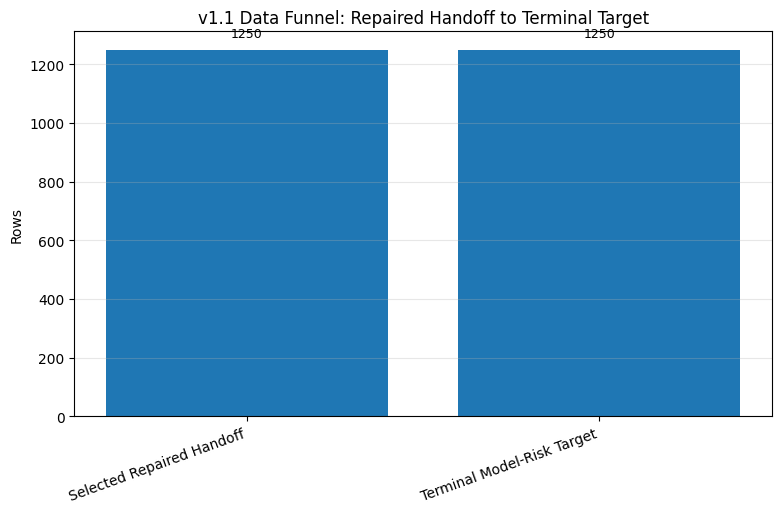

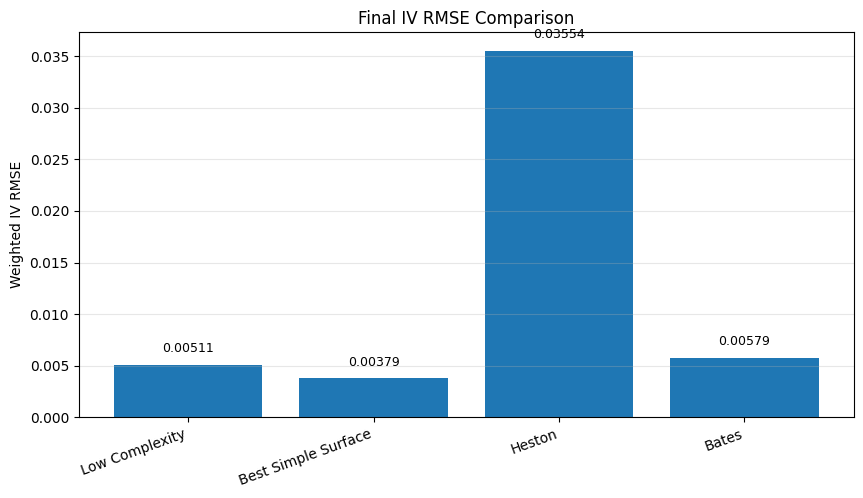

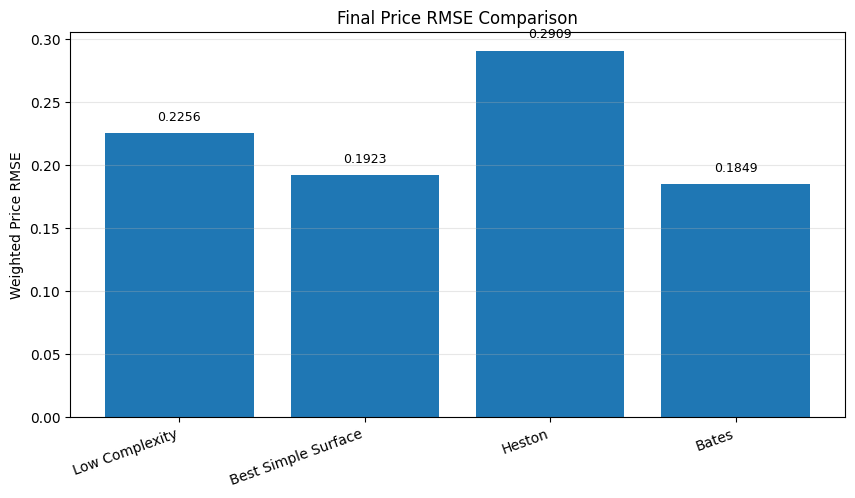

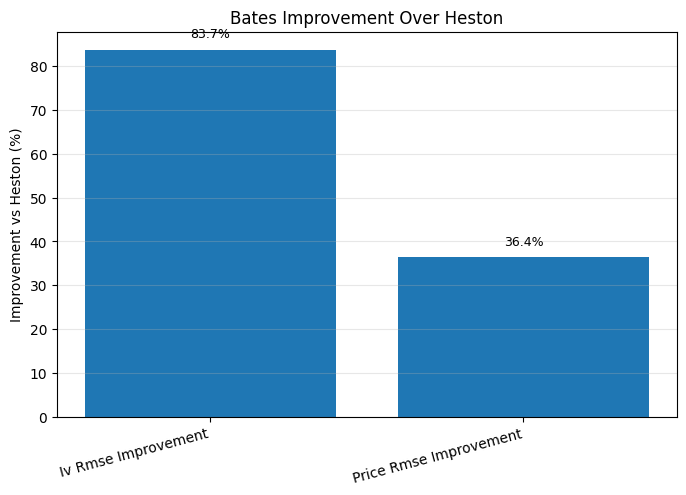

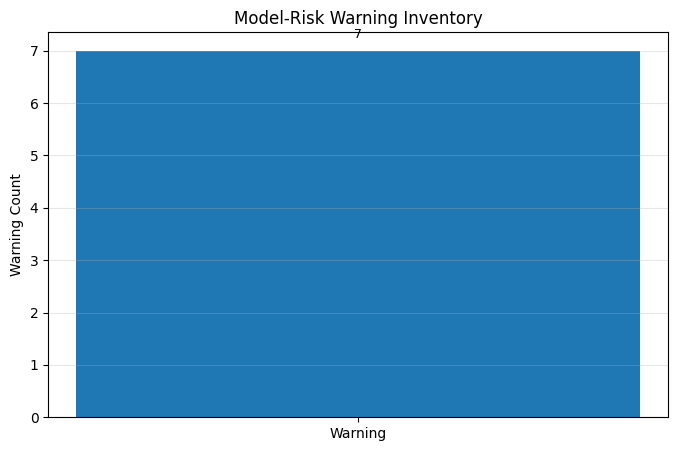

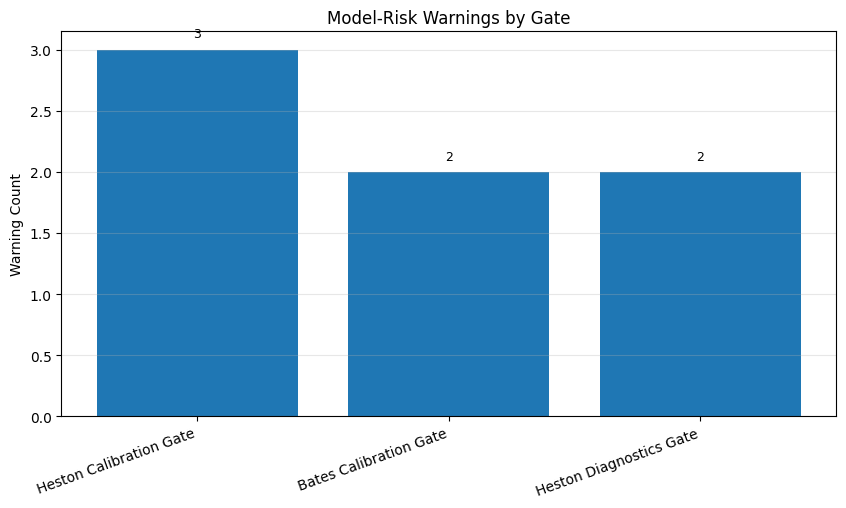

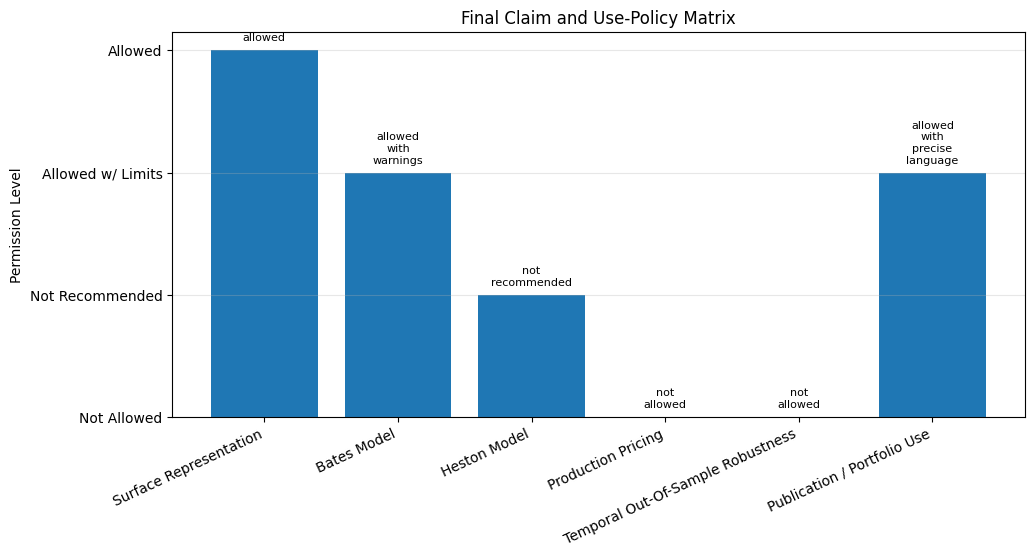

,figure_stem,png_path,png_latest_path,pdf_path,pdf_latest_path,figure_title,figure_purpose
0,n13_fig01_data_funnel,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Data funnel from repaired handoff to terminal ...,Shows that the final modeling target is based ...
1,n13_fig02_final_iv_rmse_comparison,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Final IV RMSE comparison,Shows that Bates improves over Heston but does...
2,n13_fig03_final_price_rmse_comparison,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Final price RMSE comparison,Shows Bates beating the best simple price base...
3,n13_fig04_bates_improvement_vs_heston,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Bates improvement over Heston,Shows why Bates is preferred over Heston as th...
4,n13_fig05_model_risk_warning_inventory,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Model-risk warning inventory,Summarizes the remaining warning burden behind...
5,n13_fig06_model_risk_warnings_by_gate,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Model-risk warnings by gate,Shows which validation gates drive the remaini...
6,n13_fig07_claim_use_policy_matrix,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,Final claim and use-policy matrix,Makes the permitted and blocked claims visuall...


,figure_group,interpretation
0,data_funnel,The final target is produced from the repaired...
1,iv_rmse,Bates materially improves over Heston but fail...
2,price_rmse,"Bates performs well in price space, which supp..."
3,model_risk,The warning inventory explains why the termina...
4,use_policy,The project explicitly allows surface represen...


Notebook 13 final report figures complete.
Figure registry: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_figure_registry_latest.csv
Figure manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_figure_manifest_latest.json


In [9]:
# ============================================================
# Notebook 13 — Final report figures
# ============================================================
#
# Purpose:
#   Generate the small set of reader-facing figures needed for:
#       - GitHub README
#       - final report
#       - project summary
#
# Figure discipline:
#   - No new modeling.
#   - No recalibration.
#   - No surface repair.
#   - No excessive plot dumping.
#   - Each figure must support the final research claim.
# ============================================================


# ------------------------------------------------------------
# Figure helpers
# ------------------------------------------------------------

def save_current_figure(stem: str, output_dir: Path = N13_FIGURE_DIR) -> dict[str, str]:
    """
    Save the current matplotlib figure as timestamped/latest PNG and PDF.

    Returns
    -------
    dict[str, str]
        Paths for timestamped/latest PNG/PDF files.
    """
    png_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}.png"
    png_latest_path = output_dir / f"{stem}_latest.png"

    pdf_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}.pdf"
    pdf_latest_path = output_dir / f"{stem}_latest.pdf"

    plt.savefig(png_path, bbox_inches="tight", dpi=160)
    plt.savefig(png_latest_path, bbox_inches="tight", dpi=160)
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(pdf_latest_path, bbox_inches="tight")

    return {
        "figure_stem": stem,
        "png_path": str(png_path),
        "png_latest_path": str(png_latest_path),
        "pdf_path": str(pdf_path),
        "pdf_latest_path": str(pdf_latest_path),
    }


def clean_label(value: Any) -> str:
    """Convert labels to compact display strings."""
    text = str(value)
    text = text.replace("_", " ")
    text = text.replace(" calibrated", "")
    text = text.replace(" reference", "")
    return text.title()


def numeric_series(df: pd.DataFrame, col: str) -> pd.Series:
    """Return numeric Series with non-finite values removed."""
    values = pd.to_numeric(df[col], errors="coerce")
    return values.replace([np.inf, -np.inf], np.nan)


def annotate_bars(ax: plt.Axes, values: list[float], fmt: str = "{:.4f}") -> None:
    """Place numeric labels above bars."""
    if not values:
        return

    finite_values = [v for v in values if pd.notna(v)]

    if not finite_values:
        return

    ymax = max(finite_values)

    for idx, value in enumerate(values):
        if pd.isna(value):
            continue

        ax.text(
            idx,
            value + ymax * 0.025,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=0,
        )


figure_registry_rows: list[dict[str, str]] = []


# ------------------------------------------------------------
# Figure 1 — Data funnel
# ------------------------------------------------------------

data_funnel_plot_df = data_funnel.copy()
data_funnel_plot_df["rows_plot"] = pd.to_numeric(data_funnel_plot_df["rows"], errors="coerce")

funnel_available = data_funnel_plot_df.dropna(subset=["rows_plot"]).copy()

if not funnel_available.empty:
    plt.figure(figsize=(9, 5))

    x_labels = funnel_available["stage"].astype(str).map(clean_label).tolist()
    y_values = funnel_available["rows_plot"].astype(float).tolist()

    ax = plt.gca()
    ax.bar(range(len(y_values)), y_values)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    ax.set_ylabel("Rows")
    ax.set_title("v1.1 Data Funnel: Repaired Handoff to Terminal Target")
    ax.grid(axis="y", alpha=0.3)

    annotate_bars(ax, y_values, fmt="{:.0f}")

    figure_registry_rows.append(
        {
            **save_current_figure("n13_fig01_data_funnel"),
            "figure_title": "Data funnel from repaired handoff to terminal target",
            "figure_purpose": "Shows that the final modeling target is based on the repaired handoff, not raw quotes.",
        }
    )

    plt.show()


# ------------------------------------------------------------
# Figure 2 — IV RMSE comparison
# ------------------------------------------------------------

iv_plot_df = final_model_scorecard.copy()
iv_plot_df["iv_rmse"] = numeric_series(iv_plot_df, "iv_rmse")
iv_plot_df = iv_plot_df.dropna(subset=["iv_rmse"]).copy()

if not iv_plot_df.empty:
    plt.figure(figsize=(10, 5))

    x_labels = iv_plot_df["model_or_baseline"].astype(str).map(clean_label).tolist()
    y_values = iv_plot_df["iv_rmse"].astype(float).tolist()

    ax = plt.gca()
    ax.bar(range(len(y_values)), y_values)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    ax.set_ylabel("Weighted IV RMSE")
    ax.set_title("Final IV RMSE Comparison")
    ax.grid(axis="y", alpha=0.3)

    annotate_bars(ax, y_values, fmt="{:.5f}")

    figure_registry_rows.append(
        {
            **save_current_figure("n13_fig02_final_iv_rmse_comparison"),
            "figure_title": "Final IV RMSE comparison",
            "figure_purpose": "Shows that Bates improves over Heston but does not beat the best simple IV surface.",
        }
    )

    plt.show()


# ------------------------------------------------------------
# Figure 3 — Price RMSE comparison
# ------------------------------------------------------------

price_plot_df = final_model_scorecard.copy()
price_plot_df["price_rmse"] = numeric_series(price_plot_df, "price_rmse")
price_plot_df = price_plot_df.dropna(subset=["price_rmse"]).copy()

if not price_plot_df.empty:
    plt.figure(figsize=(10, 5))

    x_labels = price_plot_df["model_or_baseline"].astype(str).map(clean_label).tolist()
    y_values = price_plot_df["price_rmse"].astype(float).tolist()

    ax = plt.gca()
    ax.bar(range(len(y_values)), y_values)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=20, ha="right")
    ax.set_ylabel("Weighted Price RMSE")
    ax.set_title("Final Price RMSE Comparison")
    ax.grid(axis="y", alpha=0.3)

    annotate_bars(ax, y_values, fmt="{:.4f}")

    figure_registry_rows.append(
        {
            **save_current_figure("n13_fig03_final_price_rmse_comparison"),
            "figure_title": "Final price RMSE comparison",
            "figure_purpose": "Shows Bates beating the best simple price baseline while still not becoming the IV-surface representation.",
        }
    )

    plt.show()


# ------------------------------------------------------------
# Figure 4 — Bates improvement over Heston
# ------------------------------------------------------------

improvement_plot_df = model_improvement_summary.copy()
improvement_plot_df = improvement_plot_df.loc[
    improvement_plot_df["value_percent"].notna()
].copy()

if not improvement_plot_df.empty:
    plt.figure(figsize=(8, 5))

    x_labels = improvement_plot_df["metric"].astype(str).map(clean_label).tolist()
    y_values = pd.to_numeric(improvement_plot_df["value_percent"], errors="coerce").astype(float).tolist()

    ax = plt.gca()
    ax.bar(range(len(y_values)), y_values)
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=15, ha="right")
    ax.set_ylabel("Improvement vs Heston (%)")
    ax.set_title("Bates Improvement Over Heston")
    ax.grid(axis="y", alpha=0.3)

    annotate_bars(ax, y_values, fmt="{:.1f}%")

    figure_registry_rows.append(
        {
            **save_current_figure("n13_fig04_bates_improvement_vs_heston"),
            "figure_title": "Bates improvement over Heston",
            "figure_purpose": "Shows why Bates is preferred over Heston as the parametric diagnostic model.",
        }
    )

    plt.show()


# ------------------------------------------------------------
# Figure 5 — Model-risk warning inventory
# ------------------------------------------------------------

warning_plot_df = warning_inventory_clean.copy() if "warning_inventory_clean" in globals() else pd.DataFrame()

if not warning_plot_df.empty:
    severity_col = get_col(warning_plot_df, ["severity", "warning_severity"])
    gate_col = get_col(warning_plot_df, ["gate_name", "gate", "validation_gate"])

    if severity_col is not None:
        warning_counts = (
            warning_plot_df
            .groupby(severity_col, as_index=False)
            .size()
            .rename(columns={"size": "count", severity_col: "severity"})
            .sort_values("count", ascending=False)
        )

        plt.figure(figsize=(8, 5))

        x_labels = warning_counts["severity"].astype(str).map(clean_label).tolist()
        y_values = warning_counts["count"].astype(float).tolist()

        ax = plt.gca()
        ax.bar(range(len(y_values)), y_values)
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels)
        ax.set_ylabel("Warning Count")
        ax.set_title("Model-Risk Warning Inventory")
        ax.grid(axis="y", alpha=0.3)

        annotate_bars(ax, y_values, fmt="{:.0f}")

        figure_registry_rows.append(
            {
                **save_current_figure("n13_fig05_model_risk_warning_inventory"),
                "figure_title": "Model-risk warning inventory",
                "figure_purpose": "Summarizes the remaining warning burden behind the conditional-pass verdict.",
            }
        )

        plt.show()

    if gate_col is not None:
        gate_warning_counts = (
            warning_plot_df
            .groupby(gate_col, as_index=False)
            .size()
            .rename(columns={"size": "count", gate_col: "gate_name"})
            .sort_values("count", ascending=False)
        )

        plt.figure(figsize=(10, 5))

        x_labels = gate_warning_counts["gate_name"].astype(str).map(clean_label).tolist()
        y_values = gate_warning_counts["count"].astype(float).tolist()

        ax = plt.gca()
        ax.bar(range(len(y_values)), y_values)
        ax.set_xticks(range(len(x_labels)))
        ax.set_xticklabels(x_labels, rotation=20, ha="right")
        ax.set_ylabel("Warning Count")
        ax.set_title("Model-Risk Warnings by Gate")
        ax.grid(axis="y", alpha=0.3)

        annotate_bars(ax, y_values, fmt="{:.0f}")

        figure_registry_rows.append(
            {
                **save_current_figure("n13_fig06_model_risk_warnings_by_gate"),
                "figure_title": "Model-risk warnings by gate",
                "figure_purpose": "Shows which validation gates drive the remaining warning inventory.",
            }
        )

        plt.show()


# ------------------------------------------------------------
# Figure 6 — Use-policy matrix
# ------------------------------------------------------------

policy_plot_df = claim_registry.copy()

permission_rank = {
    "allowed": 3,
    "allowed_with_precise_language": 2,
    "allowed_with_warnings": 2,
    "not_recommended": 1,
    "not_allowed": 0,
}

policy_plot_df["permission_score"] = (
    policy_plot_df["permission"]
    .astype(str)
    .map(permission_rank)
    .fillna(0)
    .astype(float)
)

plt.figure(figsize=(11, 5))

x_labels = policy_plot_df["claim_area"].astype(str).map(clean_label).tolist()
y_values = policy_plot_df["permission_score"].astype(float).tolist()

ax = plt.gca()
ax.bar(range(len(y_values)), y_values)
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=25, ha="right")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["Not Allowed", "Not Recommended", "Allowed w/ Limits", "Allowed"])
ax.set_ylabel("Permission Level")
ax.set_title("Final Claim and Use-Policy Matrix")
ax.grid(axis="y", alpha=0.3)

for idx, permission in enumerate(policy_plot_df["permission"].astype(str).tolist()):
    ax.text(
        idx,
        y_values[idx] + 0.06,
        permission.replace("_", "\n"),
        ha="center",
        va="bottom",
        fontsize=8,
    )

figure_registry_rows.append(
    {
        **save_current_figure("n13_fig07_claim_use_policy_matrix"),
        "figure_title": "Final claim and use-policy matrix",
        "figure_purpose": "Makes the permitted and blocked claims visually explicit.",
    }
)

plt.show()


# ------------------------------------------------------------
# Figure registry
# ------------------------------------------------------------

figure_registry = pd.DataFrame(figure_registry_rows)

figure_registry_path, figure_registry_latest_path = write_latest_and_timestamped_csv(
    figure_registry,
    "n13_figure_registry",
    N13_TABLE_DIR,
)

display(figure_registry)


# ------------------------------------------------------------
# Figure interpretation table
# ------------------------------------------------------------

figure_interpretation = pd.DataFrame(
    [
        {
            "figure_group": "data_funnel",
            "interpretation": (
                "The final target is produced from the repaired handoff layer. "
                "This prevents the project from looking like a direct calibration to raw quotes."
            ),
        },
        {
            "figure_group": "iv_rmse",
            "interpretation": (
                "Bates materially improves over Heston but fails to beat the best simple IV surface. "
                "This is the core reason Bates is diagnostic rather than representational."
            ),
        },
        {
            "figure_group": "price_rmse",
            "interpretation": (
                "Bates performs well in price space, which supports its use as a diagnostic and stress-testing model."
            ),
        },
        {
            "figure_group": "model_risk",
            "interpretation": (
                "The warning inventory explains why the terminal verdict is conditional pass rather than production ready."
            ),
        },
        {
            "figure_group": "use_policy",
            "interpretation": (
                "The project explicitly allows surface representation and publication claims with limits, "
                "while blocking production-pricing and temporal-OOS claims."
            ),
        },
    ]
)

figure_interpretation_path, figure_interpretation_latest_path = write_latest_and_timestamped_csv(
    figure_interpretation,
    "n13_figure_interpretation",
    N13_TABLE_DIR,
)

display(figure_interpretation)


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

n13_figure_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "figure_count": int(len(figure_registry)),
    "figure_registry_path": figure_registry_path,
    "figure_registry_latest_path": figure_registry_latest_path,
    "figure_interpretation_path": figure_interpretation_path,
    "figure_interpretation_latest_path": figure_interpretation_latest_path,
    "figure_output_dir": N13_FIGURE_DIR,
    "modeling_layer_should_continue": False,
}

n13_figure_manifest_path, n13_figure_manifest_latest_path = write_json_safe_latest_and_timestamped(
    n13_figure_manifest,
    "n13_figure_manifest",
    N13_MANIFEST_DIR,
)

print("Notebook 13 final report figures complete.")
print(f"Figure registry: {figure_registry_latest_path}")
print(f"Figure manifest: {n13_figure_manifest_latest_path}")

In [10]:
# ============================================================
# Notebook 13 — Final research narrative and README-ready text
# ============================================================
#
# Purpose:
#   Generate clean, reader-facing text blocks for:
#       - final report
#       - GitHub README
#       - project summary
#       - LinkedIn-safe summary
#
# This cell writes markdown/text artifacts only.
# No modeling or numerical recalculation is performed.
# ============================================================


# ------------------------------------------------------------
# Text helpers
# ------------------------------------------------------------

def write_text_latest_and_timestamped(
    text: str,
    stem: str,
    output_dir: Path,
    suffix: str = ".md",
) -> tuple[Path, Path]:
    """
    Write timestamped and latest text artifacts.
    """
    timestamped_path = output_dir / f"{stem}_{RUN_TIMESTAMP_UTC}{suffix}"
    latest_path = output_dir / f"{stem}_latest{suffix}"

    for path in [timestamped_path, latest_path]:
        path.write_text(text, encoding="utf-8")

    return timestamped_path, latest_path


def table_to_markdown_safe(df: pd.DataFrame, max_rows: int | None = None) -> str:
    """
    Convert a DataFrame to markdown safely.
    """
    if df.empty:
        return "_No table available._"

    out = df.copy()

    if max_rows is not None:
        out = out.head(max_rows)

    for col in out.columns:
        out[col] = out[col].map(
            lambda x: (
                f"{x:.6f}" if isinstance(x, (float, np.floating))
                else str(x) if x is not None
                else ""
            )
        )

    return out.to_markdown(index=False)


def metric_value(metrics_df: pd.DataFrame, metric: str, default: Any = None) -> Any:
    """
    Pull a value from the data_funnel_metrics table.
    """
    if metrics_df.empty:
        return default

    rows = metrics_df.loc[metrics_df["metric"].astype(str).eq(metric)]

    if rows.empty:
        return default

    value = rows.iloc[0]["value"]

    try:
        if pd.isna(value):
            return default
    except TypeError:
        pass

    return value


def fmt_number(value: Any, digits: int = 4, default: str = "not available") -> str:
    """
    Format numeric values for reader-facing text.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except TypeError:
        pass

    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"

    if isinstance(value, (float, np.floating)):
        return f"{float(value):,.{digits}f}"

    return str(value)


def fmt_percent(value: Any, digits: int = 1, default: str = "not available") -> str:
    """
    Format numeric values as percentages.
    """
    if value is None:
        return default

    try:
        if pd.isna(value):
            return default
    except TypeError:
        pass

    return f"{100.0 * float(value):.{digits}f}%"


# ------------------------------------------------------------
# Pull final values for text generation
# ------------------------------------------------------------

final_rows_text = fmt_number(metric_value(data_funnel_metrics, "selected_handoff_rows"), digits=0)
final_expiries_text = fmt_number(metric_value(data_funnel_metrics, "selected_handoff_expiries"), digits=0)
final_strikes_text = fmt_number(metric_value(data_funnel_metrics, "selected_handoff_unique_strikes"), digits=0)

heston_iv_text = fmt_number(heston_iv_rmse, digits=6)
heston_price_text = fmt_number(heston_price_rmse, digits=6)

bates_iv_text = fmt_number(bates_iv_rmse, digits=6)
bates_price_text = fmt_number(bates_price_rmse, digits=6)

best_simple_iv_text = fmt_number(best_simple_iv_ceiling, digits=6)
best_simple_price_text = fmt_number(best_simple_price_ceiling, digits=6)

bates_iv_improvement_text = fmt_percent(bates_iv_improvement_vs_heston, digits=1)
bates_price_improvement_text = fmt_percent(bates_price_improvement_vs_heston, digits=1)


# ------------------------------------------------------------
# Final abstract
# ------------------------------------------------------------

final_abstract = f"""
# Final Abstract — Derivative Pricing Project v1.1

This project is a self-directed derivatives-pricing and model-risk study that progresses from no-arbitrage replication and Black-Scholes foundations to empirical SPY option-chain filtering, implied-volatility inversion, static-arbitrage diagnostics, SVI/SSVI-style surface repair, and terminal Heston/Bates calibration.

The central research question is whether a calibrated parametric stochastic-volatility model is more defensible as a surface representation than a repaired/simple implied-volatility surface for a single SPY option-chain date.

The final answer is negative. The repaired/simple implied-volatility surface remains the preferred surface representation. Bates materially improves over Heston, with an IV RMSE improvement of {bates_iv_improvement_text} and a price RMSE improvement of {bates_price_improvement_text}, but it does not beat the best simple IV surface baseline. Bates is therefore useful as a parametric diagnostic and stress-testing layer, not as the final volatility-surface representation.

The terminal modeling target contains {final_rows_text} rows across {final_expiries_text} expiries and {final_strikes_text} unique strikes. The final verdict is `{final_verdict}` with model-risk level `{model_risk_level}`.

No production-pricing, trading-readiness, or temporal out-of-sample robustness claim is made.
""".strip()


# ------------------------------------------------------------
# README-ready markdown
# ------------------------------------------------------------

readme_markdown = f"""
# Derivative Pricing Project v1.1

## Overview

This repository contains a self-directed derivatives-pricing research project.

The project starts from first principles and builds toward an empirical SPY volatility-surface and model-risk study:

1. no-arbitrage replication and binomial pricing
2. Brownian motion, GBM, quadratic variation, and Ito calculus
3. Black-Scholes PDE, formula, Greeks, and numerical checks
4. risk-neutral Monte Carlo and discrete delta-hedging error
5. implied-volatility inversion and no-arbitrage bounds
6. SPY option-chain ingestion and quote filtering
7. static-arbitrage diagnostics for empirical IV surfaces
8. SVI/SSVI-style repaired-surface construction
9. Heston/Bates calibration and model-risk validation
10. final synthesis and claim discipline

## Research question

For a single SPY option-chain date, is a calibrated parametric stochastic-volatility model more defensible as a volatility-surface representation than a repaired/simple implied-volatility surface?

## Main finding

No.

For the single SPY quote date studied, the repaired/simple implied-volatility surface remains the preferred surface representation.

Bates materially improves over Heston:

- IV RMSE improvement vs Heston: **{bates_iv_improvement_text}**
- Price RMSE improvement vs Heston: **{bates_price_improvement_text}**

However, Bates does **not** beat the best simple IV surface baseline:

- best simple IV RMSE: **{best_simple_iv_text}**
- Bates IV RMSE: **{bates_iv_text}**

Therefore, Bates is useful as a parametric diagnostic and stress-testing layer, but not as the final volatility-surface representation.

## Final model-use policy

| Use case | Decision |
|---|---|
| Surface representation | Use `{selected_surface_model}` / repaired-simple IV surface |
| Parametric diagnostic model | Use `{selected_parametric_model}` with warnings |
| Heston final model | Not recommended |
| Production pricing | Not allowed |
| Temporal out-of-sample claim | Not allowed |
| Publication / portfolio use | Allowed only with precise limitations |

## Terminal target

The final modeling target contains:

- rows: **{final_rows_text}**
- expiries: **{final_expiries_text}**
- unique strikes: **{final_strikes_text}**

The final verdict is:

> `{final_verdict}`

Model-risk level:

> `{model_risk_level}`

## Key numerical results

| Model / baseline | IV RMSE | Price RMSE | Role |
|---|---:|---:|---|
| Best simple surface | {best_simple_iv_text} | {best_simple_price_text} | Preferred surface representation |
| Heston calibrated | {heston_iv_text} | {heston_price_text} | Negative-control parametric model |
| Bates calibrated | {bates_iv_text} | {bates_price_text} | Preferred parametric diagnostic model |

## What this project does not claim

This project does not claim:

- production pricing readiness
- live trading readiness
- temporal out-of-sample robustness
- that Bates dominates all simpler IV-surface baselines
- that the single-date result generalizes across regimes
- that the calibrated parametric model should replace the repaired/simple IV surface

## Correct interpretation

The useful result is not that the most complex model wins.

The useful result is the boundary:

> Complexity earned diagnostic value, not pricing authority.

The repaired/simple IV surface remains the better representation object. Bates is useful for parametric diagnostics and stress testing. Heston is retained only as a negative-control stochastic-volatility benchmark.
""".strip()


# ------------------------------------------------------------
# Final report markdown
# ------------------------------------------------------------

final_report_markdown = f"""
# Derivative Pricing Project v1.1 — Final Research Synthesis

## 1. Research purpose

This notebook consolidates the completed v1.1 derivative-pricing workflow into a final research synthesis.

Notebook 13 does not introduce new models, pull new market data, repair new surfaces, or recalibrate Heston/Bates. It only summarizes the completed evidence from the v1.1 pipeline.

## 2. Research question

For a single SPY option-chain date, is a calibrated parametric stochastic-volatility model more defensible as a volatility-surface representation than a repaired/simple implied-volatility surface?

## 3. Workflow summary

{table_to_markdown_safe(pipeline_map[["notebook", "primary_role", "status", "claim_contribution"]])}

## 4. Data funnel

{table_to_markdown_safe(data_funnel)}

The final modeling target is not raw option-chain data. It passes through quote filtering, IV inversion, surface-grade filtering, static-arbitrage diagnostics, and repaired-surface handoff construction.

## 5. Final model comparison

{table_to_markdown_safe(final_model_scorecard)}

## 6. Decision matrix

{table_to_markdown_safe(model_decision_matrix)}

## 7. Model-risk warnings

{table_to_markdown_safe(warning_inventory_clean if "warning_inventory_clean" in globals() else pd.DataFrame())}

## 8. Final verdict

The final verdict is `{final_verdict}`.

The preferred surface representation is `{selected_surface_model}`.

The preferred parametric diagnostic model is `{selected_parametric_model}`.

Heston is not recommended as the final calibrated model.

## 9. Interpretation

Bates materially improves over Heston, but it does not beat the best simple IV surface baseline on IV RMSE. This means the calibrated Bates model earns diagnostic and stress-testing value, but not surface-representation authority.

The repaired/simple implied-volatility surface remains the preferred representation object.

## 10. Limitations

The main limitations are:

- single quote date
- no temporal out-of-sample validation
- no production-pricing claim
- no trading-readiness claim
- remaining model-risk warnings
- Heston and Bates Feller-condition warnings
- Bates boundary-hit warnings
- Bates failure against the best simple IV surface baseline

## 11. Final recommendation

Use the repaired/simple IV surface for representation.

Use Bates only as a parametric diagnostic and stress-testing layer.

Treat Heston as a negative-control stochastic-volatility model.

Stop the v1.1 modeling layer here.
""".strip()


# ------------------------------------------------------------
# LinkedIn-safe post
# ------------------------------------------------------------

linkedin_post = f"""
I completed v1.1 of a self-directed derivatives-pricing research project.

The project starts from no-arbitrage replication and Black-Scholes foundations, then moves into SPY option-chain filtering, implied-volatility inversion, static-arbitrage diagnostics, SVI/SSVI-style surface repair, and Heston/Bates calibration.

The main result was not that the most complex model won.

For the single SPY quote date studied, the repaired/simple implied-volatility surface remained the more defensible surface representation. Bates materially improved over Heston and was useful as a parametric diagnostic/stress-testing layer, but it did not beat the best simple IV surface baseline on IV RMSE.

Final stance:

- repaired/simple IV surface: preferred representation
- Bates: useful diagnostic/stress model, with warnings
- Heston: negative-control stochastic-volatility baseline
- production pricing: not claimed
- temporal OOS robustness: not claimed

The useful result was the boundary: complexity earned diagnostic value, not pricing authority.
""".strip()


# ------------------------------------------------------------
# Claim-safe one-paragraph summary
# ------------------------------------------------------------

one_paragraph_summary = (
    "Derivative Pricing Project v1.1 is a theory-first, no-arbitrage-aware volatility-surface "
    "study that progresses from replication and Black-Scholes foundations to empirical SPY "
    "IV construction, static-arbitrage diagnostics, SVI/SSVI-style repair, and Heston/Bates "
    "model-risk validation. For the single SPY quote date studied, the repaired/simple IV "
    "surface remains the preferred surface representation. Bates materially improves over "
    "Heston and is useful as a parametric diagnostic/stress-testing layer, but it does not "
    "beat the best simple IV surface baseline on IV RMSE. No production-pricing or temporal "
    "out-of-sample claim is made."
)


# ------------------------------------------------------------
# Save text artifacts
# ------------------------------------------------------------

final_abstract_path, final_abstract_latest_path = write_text_latest_and_timestamped(
    final_abstract,
    "n13_final_abstract",
    N13_REPORT_DIR,
    suffix=".md",
)

readme_path, readme_latest_path = write_text_latest_and_timestamped(
    readme_markdown,
    "n13_readme_draft",
    N13_REPORT_DIR,
    suffix=".md",
)

final_report_path, final_report_latest_path = write_text_latest_and_timestamped(
    final_report_markdown,
    "n13_final_research_report",
    N13_REPORT_DIR,
    suffix=".md",
)

linkedin_path, linkedin_latest_path = write_text_latest_and_timestamped(
    linkedin_post,
    "n13_linkedin_post_draft",
    N13_REPORT_DIR,
    suffix=".md",
)

one_paragraph_path, one_paragraph_latest_path = write_text_latest_and_timestamped(
    one_paragraph_summary,
    "n13_one_paragraph_summary",
    N13_REPORT_DIR,
    suffix=".txt",
)


# ------------------------------------------------------------
# Text artifact registry
# ------------------------------------------------------------

text_artifact_registry = pd.DataFrame(
    [
        {
            "artifact": "final_abstract",
            "purpose": "Paper/report abstract",
            "path": str(final_abstract_path),
            "latest_path": str(final_abstract_latest_path),
        },
        {
            "artifact": "readme_draft",
            "purpose": "GitHub README starting point",
            "path": str(readme_path),
            "latest_path": str(readme_latest_path),
        },
        {
            "artifact": "final_research_report",
            "purpose": "Markdown final report",
            "path": str(final_report_path),
            "latest_path": str(final_report_latest_path),
        },
        {
            "artifact": "linkedin_post_draft",
            "purpose": "Claim-safe LinkedIn post",
            "path": str(linkedin_path),
            "latest_path": str(linkedin_latest_path),
        },
        {
            "artifact": "one_paragraph_summary",
            "purpose": "Short project summary",
            "path": str(one_paragraph_path),
            "latest_path": str(one_paragraph_latest_path),
        },
    ]
)

text_artifact_registry_path, text_artifact_registry_latest_path = write_latest_and_timestamped_csv(
    text_artifact_registry,
    "n13_text_artifact_registry",
    N13_TABLE_DIR,
)

display(text_artifact_registry)


# ------------------------------------------------------------
# Preview final abstract and README summary
# ------------------------------------------------------------

print("FINAL ABSTRACT")
print("-" * 80)
print(final_abstract)

print("\nREADME DRAFT")
print("-" * 80)
print(readme_markdown[:2500] + "\n\n[README draft continues in saved artifact...]")


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

n13_text_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "final_abstract_path": final_abstract_path,
    "final_abstract_latest_path": final_abstract_latest_path,
    "readme_path": readme_path,
    "readme_latest_path": readme_latest_path,
    "final_report_path": final_report_path,
    "final_report_latest_path": final_report_latest_path,
    "linkedin_path": linkedin_path,
    "linkedin_latest_path": linkedin_latest_path,
    "one_paragraph_path": one_paragraph_path,
    "one_paragraph_latest_path": one_paragraph_latest_path,
    "text_artifact_registry_path": text_artifact_registry_path,
    "text_artifact_registry_latest_path": text_artifact_registry_latest_path,
    "final_verdict": final_verdict,
    "selected_surface_model": selected_surface_model,
    "selected_parametric_model": selected_parametric_model,
    "modeling_layer_should_continue": False,
}

n13_text_manifest_path, n13_text_manifest_latest_path = write_json_safe_latest_and_timestamped(
    n13_text_manifest,
    "n13_text_manifest",
    N13_MANIFEST_DIR,
)

print("\nNotebook 13 final research narrative complete.")
print(f"README draft: {readme_latest_path}")
print(f"Final report: {final_report_latest_path}")
print(f"Text manifest: {n13_text_manifest_latest_path}")

,artifact,purpose,path,latest_path
0,final_abstract,Paper/report abstract,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
1,readme_draft,GitHub README starting point,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
2,final_research_report,Markdown final report,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
3,linkedin_post_draft,Claim-safe LinkedIn post,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...
4,one_paragraph_summary,Short project summary,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,D:\Derivative Pricing Project v1.0+\V1.1\outpu...


FINAL ABSTRACT
--------------------------------------------------------------------------------
# Final Abstract — Derivative Pricing Project v1.1

This project is a self-directed derivatives-pricing and model-risk study that progresses from no-arbitrage replication and Black-Scholes foundations to empirical SPY option-chain filtering, implied-volatility inversion, static-arbitrage diagnostics, SVI/SSVI-style surface repair, and terminal Heston/Bates calibration.

The central research question is whether a calibrated parametric stochastic-volatility model is more defensible as a surface representation than a repaired/simple implied-volatility surface for a single SPY option-chain date.

The final answer is negative. The repaired/simple implied-volatility surface remains the preferred surface representation. Bates materially improves over Heston, with an IV RMSE improvement of 83.7% and a price RMSE improvement of 36.4%, but it does not beat the best simple IV surface baseline. Bates is

In [11]:
# ============================================================
# Notebook 13 — Reproducibility package and final audit
# ============================================================
#
# Purpose:
#   Build the final reproducibility index for v1.1 synthesis.
#
# This cell checks that Notebook 13 produced the expected synthesis artifacts:
#   - tables
#   - figures
#   - reports
#   - manifests
#
# It also writes the final audit table and stop statement.
#
# No modeling, recalibration, market-data pull, or surface repair is performed.
# ============================================================


# ------------------------------------------------------------
# File inventory helpers
# ------------------------------------------------------------

def inventory_directory(directory: Path, label: str) -> pd.DataFrame:
    """
    Inventory files in a directory recursively.
    """
    if not directory.exists():
        return pd.DataFrame(
            columns=[
                "artifact_group",
                "path",
                "relative_path",
                "suffix",
                "size_bytes",
                "modified_utc",
            ]
        )

    rows = []

    for path in sorted(directory.rglob("*")):
        if not path.is_file():
            continue

        stat = path.stat()

        rows.append(
            {
                "artifact_group": label,
                "path": str(path),
                "relative_path": str(path.relative_to(N13_OUTPUT_DIR)),
                "suffix": path.suffix.lower(),
                "size_bytes": int(stat.st_size),
                "modified_utc": datetime.fromtimestamp(
                    stat.st_mtime,
                    tz=timezone.utc,
                ).isoformat(),
            }
        )

    return pd.DataFrame(rows)


def latest_exists(path: Path | str | None) -> bool:
    """
    Check whether a latest artifact exists.
    """
    if path is None:
        return False

    return Path(path).exists()


def check_latest_artifact(name: str, path: Path | str | None, required: bool = True) -> dict[str, Any]:
    """
    Build one final audit check row.
    """
    return {
        "check_name": name,
        "required": bool(required),
        "path": str(path) if path is not None else None,
        "passes": latest_exists(path),
    }


# ------------------------------------------------------------
# Build full N13 artifact inventory
# ------------------------------------------------------------

n13_table_inventory = inventory_directory(N13_TABLE_DIR, "tables")
n13_figure_inventory = inventory_directory(N13_FIGURE_DIR, "figures")
n13_report_inventory = inventory_directory(N13_REPORT_DIR, "reports")
n13_manifest_inventory = inventory_directory(N13_MANIFEST_DIR, "manifest")
n13_log_inventory = inventory_directory(N13_LOG_DIR, "logs")

n13_full_artifact_inventory = pd.concat(
    [
        n13_table_inventory,
        n13_figure_inventory,
        n13_report_inventory,
        n13_manifest_inventory,
        n13_log_inventory,
    ],
    ignore_index=True,
)

n13_full_artifact_inventory_path, n13_full_artifact_inventory_latest_path = write_latest_and_timestamped_csv(
    n13_full_artifact_inventory,
    "n13_full_artifact_inventory",
    N13_TABLE_DIR,
)

display(n13_full_artifact_inventory)


# ------------------------------------------------------------
# Required final checks
# ------------------------------------------------------------

final_audit_rows = [
    check_latest_artifact(
        "run_config_written",
        N13_RUN_CONFIG_LATEST_PATH,
        required=True,
    ),
    check_latest_artifact(
        "input_manifest_written",
        n13_input_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "claim_manifest_written",
        n13_claim_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "pipeline_manifest_written",
        n13_pipeline_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "data_funnel_manifest_written",
        n13_data_funnel_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "model_comparison_manifest_written",
        n13_model_comparison_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "figure_manifest_written",
        n13_figure_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "text_manifest_written",
        n13_text_manifest_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "claim_registry_written",
        claim_registry_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "project_stance_summary_written",
        project_stance_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "pipeline_map_written",
        pipeline_map_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "data_funnel_written",
        data_funnel_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "model_scorecard_written",
        final_model_scorecard_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "model_decision_matrix_written",
        model_decision_matrix_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "figure_registry_written",
        figure_registry_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "readme_draft_written",
        readme_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "final_report_written",
        final_report_latest_path,
        required=True,
    ),
    check_latest_artifact(
        "linkedin_post_written",
        linkedin_latest_path,
        required=True,
    ),
    {
        "check_name": "no_new_market_data_pull",
        "required": True,
        "path": None,
        "passes": bool(NO_NEW_MARKET_DATA_PULL),
    },
    {
        "check_name": "no_new_calibration",
        "required": True,
        "path": None,
        "passes": bool(NO_NEW_CALIBRATION),
    },
    {
        "check_name": "no_new_surface_repair",
        "required": True,
        "path": None,
        "passes": bool(NO_NEW_SURFACE_REPAIR),
    },
    {
        "check_name": "no_monte_carlo",
        "required": True,
        "path": None,
        "passes": bool(NO_MONTE_CARLO),
    },
    {
        "check_name": "no_production_pricing_claim",
        "required": True,
        "path": None,
        "passes": bool(NO_PRODUCTION_PRICING_CLAIM),
    },
    {
        "check_name": "no_temporal_oos_claim",
        "required": True,
        "path": None,
        "passes": bool(NO_TEMPORAL_OOS_CLAIM),
    },
    {
        "check_name": "modeling_layer_should_continue",
        "required": True,
        "path": None,
        "passes": False,
    },
    {
        "check_name": "v1_1_modeling_layer_complete",
        "required": True,
        "path": None,
        "passes": True,
    },
]

final_audit = pd.DataFrame(final_audit_rows)

final_audit["status"] = np.where(final_audit["passes"], "PASS", "FAIL")
final_audit["blocking_failure"] = final_audit["required"] & ~final_audit["passes"]


# The modeling-layer continuation check is expected to be False.
# Convert that row into an explicit PASS because "should_continue == False" is the desired state.
expected_false_checks = {"modeling_layer_should_continue"}

mask_expected_false = final_audit["check_name"].isin(expected_false_checks)

final_audit.loc[mask_expected_false, "status"] = np.where(
    final_audit.loc[mask_expected_false, "passes"].eq(False),
    "PASS",
    "FAIL",
)

final_audit.loc[mask_expected_false, "blocking_failure"] = final_audit.loc[
    mask_expected_false,
    "status",
].eq("FAIL")

final_audit_path, final_audit_latest_path = write_latest_and_timestamped_csv(
    final_audit,
    "n13_final_audit",
    N13_TABLE_DIR,
)

display(final_audit)


# ------------------------------------------------------------
# Blocking failure gate
# ------------------------------------------------------------

blocking_failures = final_audit.loc[final_audit["blocking_failure"]].copy()

if not blocking_failures.empty:
    display(blocking_failures)

    raise RuntimeError(
        "Notebook 13 final audit failed. Blocking failures:\n"
        + "\n".join(blocking_failures["check_name"].astype(str).tolist())
    )


# ------------------------------------------------------------
# Final synthesis manifest
# ------------------------------------------------------------

n13_final_manifest = {
    "project_version": PROJECT_VERSION,
    "notebook_name": NOTEBOOK_NAME,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC,
    "final_verdict": final_verdict,
    "model_risk_level": model_risk_level,
    "selected_surface_model": selected_surface_model,
    "selected_parametric_model": selected_parametric_model,
    "production_pricing_permission": production_permission,
    "temporal_oos_claim_allowed": False,
    "modeling_layer_should_continue": False,
    "v1_1_modeling_layer_complete": True,
    "n13_output_dir": N13_OUTPUT_DIR,
    "n13_table_dir": N13_TABLE_DIR,
    "n13_figure_dir": N13_FIGURE_DIR,
    "n13_report_dir": N13_REPORT_DIR,
    "n13_manifest_dir": N13_MANIFEST_DIR,
    "full_artifact_inventory_path": n13_full_artifact_inventory_path,
    "full_artifact_inventory_latest_path": n13_full_artifact_inventory_latest_path,
    "final_audit_path": final_audit_path,
    "final_audit_latest_path": final_audit_latest_path,
    "readme_latest_path": readme_latest_path,
    "final_report_latest_path": final_report_latest_path,
    "linkedin_latest_path": linkedin_latest_path,
    "figure_registry_latest_path": figure_registry_latest_path,
    "required_checks_passed": True,
    "n13_status": "COMPLETE",
}

n13_final_manifest_path, n13_final_manifest_latest_path = write_json_safe_latest_and_timestamped(
    n13_final_manifest,
    "n13_final_manifest",
    N13_MANIFEST_DIR,
)


# ------------------------------------------------------------
# Final completion summary
# ------------------------------------------------------------

final_completion_summary = pd.DataFrame(
    [
        {
            "field": "n13_status",
            "value": "COMPLETE",
        },
        {
            "field": "final_verdict",
            "value": final_verdict,
        },
        {
            "field": "model_risk_level",
            "value": model_risk_level,
        },
        {
            "field": "selected_surface_model",
            "value": selected_surface_model,
        },
        {
            "field": "selected_parametric_model",
            "value": selected_parametric_model,
        },
        {
            "field": "production_pricing_permission",
            "value": production_permission,
        },
        {
            "field": "temporal_oos_claim_allowed",
            "value": "no",
        },
        {
            "field": "modeling_layer_should_continue",
            "value": "no",
        },
        {
            "field": "v1_1_modeling_layer_complete",
            "value": "yes",
        },
        {
            "field": "readme_latest_path",
            "value": str(readme_latest_path),
        },
        {
            "field": "final_report_latest_path",
            "value": str(final_report_latest_path),
        },
        {
            "field": "final_manifest_latest_path",
            "value": str(n13_final_manifest_latest_path),
        },
    ]
)

final_completion_summary_path, final_completion_summary_latest_path = write_latest_and_timestamped_csv(
    final_completion_summary,
    "n13_final_completion_summary",
    N13_TABLE_DIR,
)

display(final_completion_summary)


print("Notebook 13 final audit complete.")
print(f"Final audit: {final_audit_latest_path}")
print(f"Final manifest: {n13_final_manifest_latest_path}")
print(f"Final completion summary: {final_completion_summary_latest_path}")
print("V1.1 research synthesis complete. Modeling layer remains stopped.")

,artifact_group,path,relative_path,suffix,size_bytes,modified_utc
0,tables,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,tables\n13_artifact_availability_audit_2026070...,.csv,5226,2026-07-06T17:49:57.559798+00:00
1,tables,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,tables\n13_artifact_availability_audit_latest.csv,.csv,5226,2026-07-06T17:49:57.559798+00:00
2,tables,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,tables\n13_data_funnel_20260706T174818Z.csv,.csv,1049,2026-07-06T18:05:18.233913+00:00
3,tables,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,tables\n13_data_funnel_interpretation_20260706...,.csv,773,2026-07-06T18:05:18.265947+00:00
4,tables,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,tables\n13_data_funnel_interpretation_latest.csv,.csv,773,2026-07-06T18:05:18.266979+00:00
...,...,...,...,...,...,...
111,manifest,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,manifest\n13_text_manifest_20260706T174818Z.json,.json,2450,2026-07-06T18:12:01.464233+00:00
112,manifest,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,manifest\n13_text_manifest_latest.json,.json,2450,2026-07-06T18:12:01.464233+00:00
113,logs,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,logs\n13_run_config_20260706T174526Z.json,.json,925,2026-07-06T17:45:26.939733+00:00
114,logs,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,logs\n13_run_config_20260706T174818Z.json,.json,925,2026-07-06T17:48:18.647614+00:00


,check_name,required,path,passes,status,blocking_failure
0,run_config_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
1,input_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
2,claim_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
3,pipeline_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
4,data_funnel_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
5,model_comparison_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
6,figure_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
7,text_manifest_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
8,claim_registry_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False
9,project_stance_summary_written,True,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,True,PASS,False


,field,value
0,n13_status,COMPLETE
1,final_verdict,CONDITIONAL_PASS
2,model_risk_level,elevated_but_usable_for_diagnostics
3,selected_surface_model,expiry_quadratic_k_iv
4,selected_parametric_model,bates_calibrated
5,production_pricing_permission,not_allowed
6,temporal_oos_claim_allowed,no
7,modeling_layer_should_continue,no
8,v1_1_modeling_layer_complete,yes
9,readme_latest_path,D:\Derivative Pricing Project v1.0+\V1.1\outpu...


Notebook 13 final audit complete.
Final audit: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_final_audit_latest.csv
Final manifest: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\manifest\n13_final_manifest_latest.json
Final completion summary: D:\Derivative Pricing Project v1.0+\V1.1\outputs\13_v1_1_research_synthesis_and_final_report\tables\n13_final_completion_summary_latest.csv
V1.1 research synthesis complete. Modeling layer remains stopped.
